# CSCI-E 115  Quantamental Model for Multi-Agent Stock Recommendation - Milestone 3 #
Team Name : Stock Buster /
Sirisom Pranivong 

---

## Table of Contents ##

<span style="color:#1E90FF;">1. Background and Problem Statement</span>  
<span style="color:#1E90FF;">2. Quantamental Model - Simple Explanation</span>  
<span style="color:#1E90FF;">3. Finance Data pipeline (update)</span>  
<span style="color:#1E90FF;">4. Quantamental Model (Random Forest Classification) & Model Evaluation</span>  
<span style="color:#1E90FF;">5. Create Hybrid score for Stock ranking</span>  
<span style="color:#1E90FF;">6. Next Step</span>  

### Background and Problem Statement

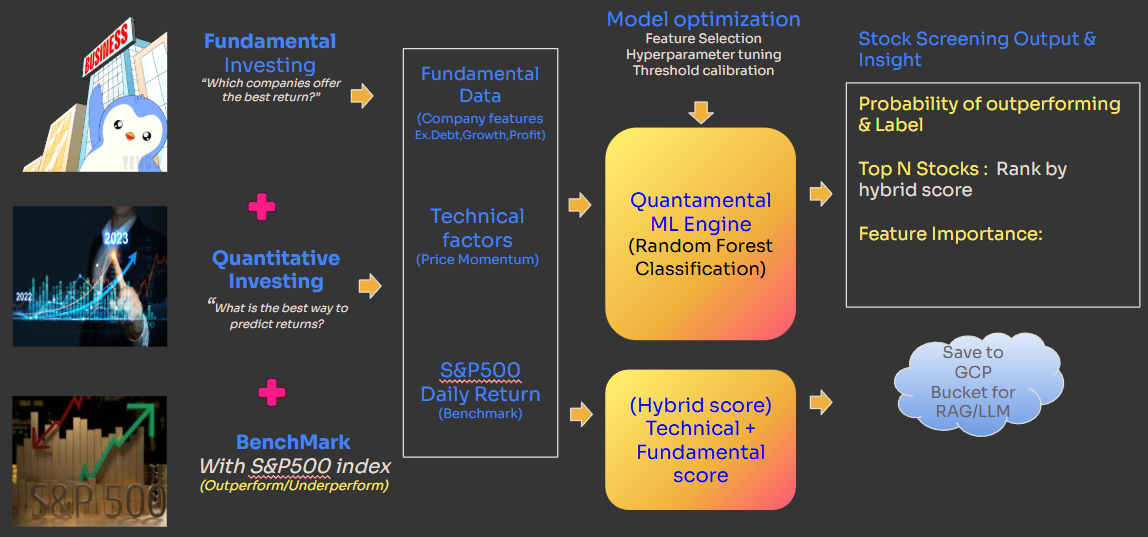

###  Quantamental Model — Simple Explanation

This project combines **finance and machine learning** to help identify which companies are likely to perform better than the market.

We bring together two types of information:

1. **Fundamental data** — these are company features like profit, revenue, debt, and cash flow.  
   They describe how strong or healthy a company is from a business perspective.

2. **Technical data** — these come from stock prices, showing trends and investor behavior.  
   For example, price momentum, volatility, or whether the stock has been moving up or down recently.

To evaluate performance, we also use a **benchmark** — the S&P 500 index — which represents the overall U.S. stock market.  
If a stock performs better than the S&P 500, we say it **outperforms**; if it does worse, it **underperforms**.

---

###  How the Model Works

1. **Data Collection**  
   We collect both *fundamental* and *technical* data for every S&P 500 company.  

2. **Feature Engineering**  
   We process the data to compute useful metrics like growth rates, moving averages, and risk measures.

3. **Machine Learning (Random Forest)**  
   The model learns patterns from historical data — for example, what characteristics were common among stocks that outperformed the S&P 500.

4. **Prediction**  
   The model predicts the **probability** that each stock will outperform in the next month.  
   Stocks with higher probabilities are stronger candidates for investment.

5. **Hybrid Score**  
   We then combine both perspectives:  
   - **Fundamental Score** (long-term business quality)  
   - **Technical Score** (short-term market trend)  
   into one **Hybrid Score** — a balanced indicator of overall potential.

6. **Result**  
   The output ranks all S&P 500 stocks by their hybrid score and provides:
   - A label (Outperform or Underperform)
   - A confidence probability
   - A list of top N recommended stocks  

Finally, results are saved to a **GCP bucket**, where they can be used by an **LLM agent** or **dashboard** for stock screening and explanation.

---

In short:  
> " The Quantamental Model blends *financial fundamentals* and *price trends* with *machine learning* to identify promising stocks — combining long-term quality with short-term momentum."



---
## Finance Data Pipeline


**Update in Milestone 3** 
**Why We Moved Away from yfinance :**

In MS2, we considered using yfinance to download historical market data.
However, we faced two major issues:

- Rate limits: yfinance frequently blocks or throttles requests when fetching data for hundreds of tickers.

- Data quality: Some tickers had missing or inconsistent values, and certain delisted stocks returned incomplete histories.

To address this, we switched to Financial Modeling Prep (FMP) because it provides:

- Reliable OHLCV and fundamental data.

- Both quarterly and annual reports.

- Faster downloads using asynchronous requests (aiohttp).

- .parquet caching for speed and reproducibility.


This change significantly improved data completeness, speed, and reliability for our quantamental pipeline.

**2. Quantamental Model (Random Forest Classification)**
    
- Adding Quantamental Model (which is based on Random forest classification)

**3. Create Hybrid score for Stock ranking**

- Create Hybrid Score which combines the fundamental features and technical features together

The snapshot above demonstrates end to end flow of Quantamental model we plan to implement

In [16]:
#Load Library
import os
import asyncio
import aiohttp
import pandas as pd
import numpy as np
from datetime import date
from dateutil.relativedelta import relativedelta
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler



#Set display to prevent jupyter notebook crashed due to large volume of output from API
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)


### Quantamental with Data preparation

**1.Configuration**

We first define the configuration parameters for the pipeline:

- DATA_DIR — local cache directory for data files

- FMP_API_KEY — our Financial Modeling Prep API key

- START and END — define the date range (last 3 years)

- Base API URLs and request headers

In [2]:
# -----------------------------
# CONFIG
# -----------------------------
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

FMP_API_KEY = os.environ.get("FMP_API_KEY", "VXTY4Jz8jYbQ9R4PjjkmqJ8VLROXlC3Z")
BASE = "https://financialmodelingprep.com"
HEADERS = {"User-Agent": "stockbusters/1.0"}

START = (date.today() - relativedelta(years=3)).isoformat()
END = date.today().isoformat()

print(f"** Pipeline setup complete | Range: {START} → {END}")

** Pipeline setup complete | Range: 2022-10-27 → 2025-10-27


**2. Sorting Helpers**

Before merging datasets, we make sure every record is strictly sorted by symbol and date.
The helper function strict_sort_for_asof() ensures:

- Each stock’s data is in chronological order

- Duplicate or invalid dates are removed

- Non-monotonic time series are automatically fixed

This prevents merge errors when aligning price and fundamentals by time.

In [3]:
# ================================================================
#  SORTING HELPERS Function
# ================================================================

def strict_sort_for_asof(df, sym_col="symbol", date_col="date"):
    """Ensure dataframe is strictly sorted and monotonic within each symbol."""
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df[sym_col] = df[sym_col].astype(str)

    df = df.dropna(subset=[sym_col, date_col])
    df = df.drop_duplicates(subset=[sym_col, date_col], keep="last")
    df = df.sort_values([sym_col, date_col], kind="mergesort").reset_index(drop=True)

    bad = df.groupby(sym_col)[date_col].apply(lambda s: (s.diff() < pd.Timedelta(0)).any())
    offenders = bad[bad].index.tolist()
    if offenders:
        print(f"!!! Found {len(offenders)} unsorted symbols — fixing...")
        fixed = [
            g.sort_values(date_col) for _, g in df.groupby(sym_col, sort=False)
        ]
        df = pd.concat(fixed, ignore_index=True)

    return df

**3. Technical Factor Computation**


We calculate key **technical indicators** using the function `add_technical_factors()`.  
These indicators capture **market momentum**, **trend strength**, and **volatility** for each stock.

| **Indicator** | **Description** | **Purpose** |
|----------------|-----------------|--------------|
| **Return (1 month)** | % change over 21 trading days | Measures short-term price momentum |
| **EMA 12 / EMA 26** | Exponential Moving Averages | Smooths price trends to highlight direction |
| **MACD** | `EMA(12) − EMA(26)` | Identifies bullish or bearish momentum shifts |
| **RSI (14)** | Relative Strength Index | Detects overbought or oversold market conditions |
| **Volatility (21d)** | Rolling standard deviation of daily returns | Acts as a proxy for price risk or uncertainty |

Each metric is computed **per symbol** using grouped transformations to ensure every stock is processed independently.  
Small missing values are **forward-filled** to maintain feature continuity for machine learning models.

In [ ]:
# ================================================================
#  TECHNICAL FACTORS CALCULATION (updated fixed error)
# ================================================================

def add_technical_factors(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute key technical indicators per symbol, ensuring alignment:
      - 1M and 1D returns
      - EMA(12), EMA(26), MACD, MACD signal & histogram
      - RSI(14)
      - 21D volatility (rolling std of daily returns)
    """
    # Ensure sorted by symbol/date
    df = df.sort_values(["symbol", "date"]).reset_index(drop=True)
    g = df.groupby("symbol", group_keys=False)

    # --- Returns ---
    df["return_1m"] = g["close"].transform(lambda x: x.pct_change(21))
    df["return_1d"] = g["close"].transform(lambda x: x.pct_change(1))

    # --- EMAs & MACD ---
    df["ema_12"] = g["close"].transform(lambda x: x.ewm(span=12, adjust=False).mean())
    df["ema_26"] = g["close"].transform(lambda x: x.ewm(span=26, adjust=False).mean())
    df["macd"] = df["ema_12"] - df["ema_26"]
    df["macd_signal"] = g["macd"].transform(lambda x: x.ewm(span=9, adjust=False).mean())
    df["macd_hist"] = df["macd"] - df["macd_signal"]

    # --- RSI (14-day) ---
    delta = g["close"].transform(lambda x: x.diff())
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = g["symbol"].transform(lambda x: gain.rolling(14, min_periods=5).mean())
    avg_loss = g["symbol"].transform(lambda x: loss.rolling(14, min_periods=5).mean())
    rs = avg_gain / (avg_loss + 1e-9)
    df["RSI_14"] = 100 - (100 / (1 + rs))

    # --- Volatility (21-day) ---
    df["volatility_21d"] = g["close"].transform(
        lambda x: x.pct_change().rolling(21, min_periods=5).std()
    )

    # --- Fill tail NaNs ---
    df[["RSI_14", "volatility_21d"]] = df.groupby("symbol")[["RSI_14", "volatility_21d"]].ffill()

    return df


**4. Data Fetching with Local Cache**

We retrieve data from FMP in three parts:

-S&P 500 list — via fetch_sp500()

-OHLCV price data — via fetch_ohlcv_all()

-Fundamentals (Quarterly + Annual) — via fetch_fundamentals_combined(), which uses:

-Quarterly data as the default

-Annual data as a fallback for newer companies with limited quarterly history

All results are stored as .parquet files in the data/ directory to prevent repeated API calls.
This design makes the pipeline fast and cost-effective.

In [ ]:
# ================================================================
#  FMP FETCHERS WITH LOCAL CACHE
#  Use GenAI to guide coding and create async function
# ================================================================
async def fetch_sp500():
    async with aiohttp.ClientSession(headers=HEADERS) as sess:
        async with sess.get(f"{BASE}/api/v3/sp500_constituent?apikey={FMP_API_KEY}") as r:
            js = await r.json()
    return [x["symbol"] for x in js if "symbol" in x]


async def fetch_ohlcv_symbol(sess, symbol):
    url = f"{BASE}/api/v3/historical-price-full/{symbol}?from={START}&to={END}&apikey={FMP_API_KEY}"
    async with sess.get(url, timeout=60) as r:
        if r.status != 200:
            return None
        js = await r.json()
    hist = js.get("historical", [])
    if not hist:
        return None
    df = pd.DataFrame(hist)
    df["symbol"] = symbol
    df["date"] = pd.to_datetime(df["date"])
    return df[["symbol", "date", "open", "high", "low", "close", "adjClose", "volume"]].rename(columns={"adjClose": "adj_close"})


async def fetch_ohlcv_all(symbols, concurrency=8):
    cache_path = f"{DATA_DIR}/ohlcv_raw.parquet"
    if os.path.exists(cache_path):
        print("💾 Using cached OHLCV data")
        return pd.read_parquet(cache_path)

    connector = aiohttp.TCPConnector(limit_per_host=concurrency)
    async with aiohttp.ClientSession(headers=HEADERS, connector=connector) as sess:
        tasks = [fetch_ohlcv_symbol(sess, s) for s in symbols]
        out = []
        for fut in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="OHLCV"):
            try:
                df = await fut
                if df is not None and not df.empty:
                    out.append(df)
            except Exception:
                continue
    df_all = pd.concat(out, ignore_index=True)
    df_all.to_parquet(cache_path, index=False)
    print(f"✅ Saved cache: {cache_path}")
    return df_all


async def fetch_key_metrics_quarterly(sess, symbol):
    url = f"{BASE}/api/v3/key-metrics/{symbol}?period=quarter&limit=12&apikey={FMP_API_KEY}"
    async with sess.get(url, timeout=30) as r:
        if r.status != 200:
            return None
        js = await r.json()
    if not js:
        return None
    df = pd.DataFrame(js)
    df["symbol"] = symbol
    df["date"] = pd.to_datetime(df["date"])
    return df.dropna(subset=["date"])


# ================================================================
#  COMBINED FUNDAMENTALS FETCHER (Quarterly + Annual fallback)
# This is to use Annual fundamental data when Quarterly data is not exist.
# This helps the company which are part of S&P500 less than 3 years
# ================================================================
async def fetch_fundamentals_combined(symbols, concurrency=8):
    cache_path = f"{DATA_DIR}/fundamentals_combined.parquet"
    if os.path.exists(cache_path):
        print("💾 Using cached fundamentals (combined)")
        return pd.read_parquet(cache_path)

    async def fetch_key_metrics(sess, symbol, period="quarter"):
        """Helper to fetch either quarterly or annual fundamentals."""
        url = f"{BASE}/api/v3/key-metrics/{symbol}?period={period}&limit=12&apikey={FMP_API_KEY}"
        async with sess.get(url, timeout=30) as r:
            if r.status != 200:
                return None
            js = await r.json()
        if not js:
            return None
        df = pd.DataFrame(js)
        df["symbol"] = symbol
        df["date"] = pd.to_datetime(df["date"])
        df["period_type"] = period
        return df.dropna(subset=["date"])

    connector = aiohttp.TCPConnector(limit_per_host=concurrency)
    async with aiohttp.ClientSession(headers=HEADERS, connector=connector) as sess:
        quarterly_tasks = [fetch_key_metrics(sess, s, "quarter") for s in symbols]
        annual_tasks = [fetch_key_metrics(sess, s, "annual") for s in symbols]

        all_quarterly, all_annual = [], []
        print("📆 Fetching quarterly fundamentals...")
        for fut in tqdm(asyncio.as_completed(quarterly_tasks), total=len(quarterly_tasks)):
            df = await fut
            if df is not None and not df.empty:
                all_quarterly.append(df)

        print("📅 Fetching annual fundamentals (fallback)...")
        for fut in tqdm(asyncio.as_completed(annual_tasks), total=len(annual_tasks)):
            df = await fut
            if df is not None and not df.empty:
                all_annual.append(df)

    # Combine both datasets
    funda_q = pd.concat(all_quarterly, ignore_index=True) if all_quarterly else pd.DataFrame()
    funda_a = pd.concat(all_annual, ignore_index=True) if all_annual else pd.DataFrame()

    print(f"Quarterly fundamentals: {len(funda_q)} rows, Annual fundamentals: {len(funda_a)} rows")

    # Fill missing quarterly data with annual fallback
    combined = pd.concat([funda_q, funda_a], ignore_index=True)
    combined = combined.sort_values(["symbol", "date", "period_type"], ascending=[True, True, False])
    combined = combined.drop_duplicates(subset=["symbol", "date"], keep="first")

    combined.to_parquet(cache_path, index=False)
    print(f"✅ Saved combined fundamentals → {cache_path}")

    return combined

async def fetch_fundamentals_quarterly(symbols, concurrency=8):
    cache_path = f"{DATA_DIR}/fundamentals_quarterly.parquet"
    if os.path.exists(cache_path):
        print("💾 Using cached fundamentals")
        return pd.read_parquet(cache_path)

    connector = aiohttp.TCPConnector(limit_per_host=concurrency)
    async with aiohttp.ClientSession(headers=HEADERS, connector=connector) as sess:
        tasks = [fetch_key_metrics_quarterly(sess, s) for s in symbols]
        out = []
        for fut in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="Quarterly Fundamentals"):
            df = await fut
            if df is not None and not df.empty:
                out.append(df)
    df_all = pd.concat(out, ignore_index=True)
    df_all.to_parquet(cache_path, index=False)
    print(f"✅ Saved cache: {cache_path}")
    return df_all


**5.Merge Technicals and Fundamentals**

The main workflow merges both technical and fundamental data using a per-symbol merge_asof() operation.
This method aligns each daily price observation with the most recent quarterly fundamental report.

After merging, small gaps may still exist due to missing report dates or market holidays.
We apply a multi-step cleaning process to ensure the dataset has no NaN or None values:

Forward-fill (ffill) small missing segments per symbol

Back-fill (bfill) early missing values

Median-fill any remaining NaN values per column

Replace infinite values from ratios like PE and PB

Drop rows or symbols with no valid fundamentals

Final NaN removal to make the dataset 100% numeric

After this process, the dataset is completely clean and safe for machine learning.

In [7]:
# ================================================================
#  MAIN WORKFLOW
# ================================================================
async def main(force_refresh=False):
    sp500 = await fetch_sp500()
    print(f"S&P 500 tickers: {len(sp500)}")

    # --- Load OHLCV ---
    if force_refresh and os.path.exists(f"{DATA_DIR}/ohlcv_raw.parquet"):
        os.remove(f"{DATA_DIR}/ohlcv_raw.parquet")
    ohlcv = await fetch_ohlcv_all(sp500)
    print("OHLCV rows:", len(ohlcv))

    # --- Compute technicals ---
    ta_path = f"{DATA_DIR}/ohlcv_with_technicals.parquet"
    if os.path.exists(ta_path):
        print("-> Using cached technicals")
        ohlcv_ta = pd.read_parquet(ta_path)
    else:
        ohlcv_ta = compute_technicals(ohlcv)
        ohlcv_ta.to_parquet(ta_path, index=False)
        print(f"-> Saved {ta_path}")

    # --- Fundamentals ---
    funda_q = await fetch_fundamentals_combined(sp500)
    print("Fundamentals shape:", funda_q.shape)

    # --- Merge ---
    keep_funda = [
        "revenuePerShare", "netIncomePerShare", "operatingCashFlowPerShare",
        "freeCashFlowPerShare", "roe", "roic", "returnOnTangibleAssets",
        "peRatio", "pbRatio", "priceToSalesRatio", "pfcfRatio",
        "debtToEquity", "currentRatio", "daysSalesOutstanding",
        "inventoryTurnover", "dividendYield", "payoutRatio"
    ]

    print("-> Starting reliable per-symbol quantamental merge...")
    merged = []
    symbols = sorted(set(ohlcv_ta["symbol"]) & set(funda_q["symbol"]))
    for sym in tqdm(symbols, desc="Merging"):
        left = ohlcv_ta.query("symbol == @sym").sort_values("date")
        right = funda_q.query("symbol == @sym").sort_values("date")
        if len(left) == 0:
            continue
        if len(right) == 0:
            for col in keep_funda:
                left[col] = np.nan
            merged.append(left)
            continue
        m = pd.merge_asof(left, right, on="date", direction="backward", allow_exact_matches=True)
        m[keep_funda] = m[keep_funda].ffill().bfill(limit=1)
        merged.append(m)

    merged = pd.concat(merged, ignore_index=True)
    merged.rename(columns={"symbol_x": "symbol"}, inplace=True)
    merged.drop(columns=["symbol_y"], inplace=True, errors="ignore")

    # --- Drop empty columns ---
    drop_cols = merged.columns[merged.isna().mean() > 0.8]
    if len(drop_cols) > 0:
        print(f"-> Dropping {len(drop_cols)} columns: {list(drop_cols)}")
        merged.drop(columns=drop_cols, inplace=True)

    # ================================================================
    #  POST-MERGE FUNDAMENTAL CLEANUP (FORWARD-FILL)
    # There are small NAN which comes from short gaps of trading holidays and missing update. 
    #  It will be filled by forward filled
    # ================================================================
    print(" Forward-filling short gaps in fundamentals...")

    funda_cols = [
        "revenuePerShare", "netIncomePerShare",
        "operatingCashFlowPerShare", "freeCashFlowPerShare",
        "roe", "roic", "returnOnTangibleAssets",
        "peRatio", "pbRatio", "priceToSalesRatio", "pfcfRatio",
        "debtToEquity", "currentRatio",
        "daysSalesOutstanding", "inventoryTurnover",
        "dividendYield", "payoutRatio"
    ]

    # Sort and forward-fill per symbol
    merged = merged.sort_values(["symbol", "date"])
    merged[funda_cols] = merged.groupby("symbol")[funda_cols].ffill(limit=5)

    # Optional: backfill one-step at the start of each symbol
    merged[funda_cols] = merged.groupby("symbol")[funda_cols].bfill(limit=1)

    # Drop any symbol still 100% NaN in fundamentals
    drop_syms = merged.groupby("symbol")[funda_cols].apply(lambda g: g.isna().all().all())
    drop_syms = drop_syms[drop_syms].index.tolist()
    if drop_syms:
        print(f"🗑️ Dropping {len(drop_syms)} symbols with no fundamentals: {drop_syms[:5]}")
        merged = merged[~merged["symbol"].isin(drop_syms)]

    #print("-> Fundamental cleanup complete:", merged.shape)

    # ================================================================
    #  FINAL MODEL-READY CLEANING (NO NaNs)
    # ================================================================
    print("-> Performing final model-ready cleaning...")

    # 1️ Replace inf values (e.g., from PE ratios)
    merged.replace([np.inf, -np.inf], np.nan, inplace=True)

    # 2️ Forward-fill + back-fill fundamentals
    merged[funda_cols] = merged.groupby("symbol")[funda_cols].ffill(limit=60)
    merged[funda_cols] = merged.groupby("symbol")[funda_cols].bfill(limit=2)

    # 3️ Fill remaining NaNs in fundamentals with per-column median
    for col in funda_cols:
        median_val = merged[col].median(skipna=True)
        merged[col] = merged[col].fillna(median_val)

    # 4️ Fill technicals and price columns with safe defaults (avoid None)
    num_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
    for col in num_cols:
        if merged[col].isna().any():
            median_val = merged[col].median(skipna=True)
            merged[col] = merged[col].fillna(median_val)

    # 5️ Drop any row that still contains NaN or None (edge case protection)
    before = len(merged)
    merged = merged.dropna(how="any").reset_index(drop=True)
    after = len(merged)
    if before != after:
        print(f"-> Dropped {before - after} residual rows with NaN/None values")

    # 6️ Verify final cleanliness
    nulls = merged.isna().sum().sum()
    if nulls == 0:
        print("-> All NaNs and None removed. Dataset 100% clean for modeling.")
    else:
        print(f"-> {nulls} NaNs remain — investigate specific columns.")

    # ================================================================
    #  SAVE FINAL DATASET
    # ================================================================
    


    output_path = f"{DATA_DIR}/quantamental_cleaned.parquet"
    merged.to_parquet(output_path, index=False)
    print(f"-> Saved cleaned quantamental dataset → {output_path}")


**7.Validation and Quality Check**

We run a final validation function validate_quantamental() to confirm the integrity of the dataset:

- Displays row counts and number of unique tickers

- Reports missing value percentages per feature

- Plots the coverage distribution by symbol

- Filters out low-coverage tickers automatically

- Saves both .parquet and .csv versions for downstream modeling

This validation step ensures that the final data is uniform and ready for modeling.


In [ ]:
################################
# Quantamental data validation
################################

def validate_quantamental(df, keep_funda, coverage_threshold_ratio=0.9, auto_filter=True):
    print(" VALIDATING QUANTAMENTAL DATASET...")
    print(f"Total rows: {len(df):,}")
    print(f"Unique symbols: {df['symbol'].nunique()}")

    nan_stats = (
        df[keep_funda].isna().mean().sort_values(ascending=False).mul(100).round(2)
    )
    print("\nList stock with high Missing Value % (Top 15):")
    print(nan_stats.head(15))

    coverage = df.groupby("symbol")["date"].count().sort_values()
    median_rows = coverage.median()
    threshold = median_rows * coverage_threshold_ratio

    plt.figure(figsize=(10, 4))
    plt.plot(range(len(coverage)), coverage.values)
    plt.title("Rows per Symbol (Coverage Distribution)")
    plt.xlabel("Symbol Index")
    plt.ylabel("Row Count")
    plt.grid(alpha=0.3)
    plt.show()

    low_cov = coverage[coverage < threshold]
    if len(low_cov) > 0:
        print(f" {len(low_cov)} low-coverage symbols found. It will be removed")
        df = df[~df["symbol"].isin(low_cov.index)]
        print(f"✅ Filtered dataset: {df['symbol'].nunique()} symbols remain.")

    df.to_parquet(f"{DATA_DIR}/quantamental_filtered.parquet", index=False)
    print("📁 Saved → quantamental_filtered.parquet")
    df.to_csv(f"{DATA_DIR}/quantamental_filtered.csv", index=False)

    return df


S&P 500 tickers: 503
💾 Using cached OHLCV data
OHLCV rows: 377650
-> Using cached technicals
💾 Using cached fundamentals (combined)
Fundamentals shape: (8235, 62)
-> Starting reliable per-symbol quantamental merge...


Merging: 100%|██████████| 503/503 [00:05<00:00, 99.10it/s] 


 Forward-filling short gaps in fundamentals...
-> Performing final model-ready cleaning...
-> Dropped 3106 residual rows with NaN/None values
-> All NaNs and None removed. Dataset 100% clean for modeling.
-> Saved cleaned quantamental dataset → ./data/quantamental_cleaned.parquet
 VALIDATING QUANTAMENTAL DATASET...
Total rows: 374,544
Unique symbols: 503

List stock with high Missing Value % (Top 15):
revenuePerShare              0.0
netIncomePerShare            0.0
operatingCashFlowPerShare    0.0
freeCashFlowPerShare         0.0
roe                          0.0
roic                         0.0
returnOnTangibleAssets       0.0
peRatio                      0.0
pbRatio                      0.0
priceToSalesRatio            0.0
pfcfRatio                    0.0
debtToEquity                 0.0
currentRatio                 0.0
daysSalesOutstanding         0.0
inventoryTurnover            0.0
dtype: float64


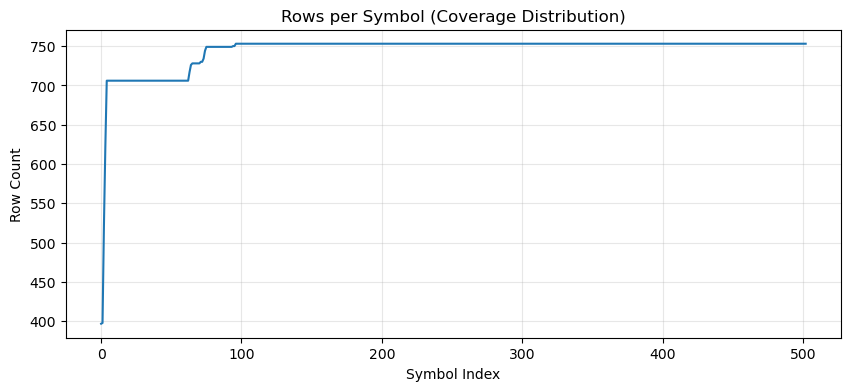

 4 low-coverage symbols found. It will be removed
✅ Filtered dataset: 499 symbols remain.
📁 Saved → quantamental_filtered.parquet


In [27]:
#########################################
# Run everything and show validation
#########################################

try:
    asyncio.get_running_loop()
    import nest_asyncio
    nest_asyncio.apply()
    await main(force_refresh=False)
except RuntimeError:
    asyncio.run(main(force_refresh=False))

df = pd.read_parquet(f"{DATA_DIR}/quantamental_cleaned.parquet")
df = validate_quantamental(df, [
    "revenuePerShare", "netIncomePerShare", "operatingCashFlowPerShare",
    "freeCashFlowPerShare", "roe", "roic", "returnOnTangibleAssets",
    "peRatio", "pbRatio", "priceToSalesRatio", "pfcfRatio",
    "debtToEquity", "currentRatio", "daysSalesOutstanding",
    "inventoryTurnover", "dividendYield", "payoutRatio"
])


In [13]:
#Fetch S&P500 for benchmarking 

async def fetch_sp500_index():
    url = f"{BASE}/api/v3/historical-price-full/%5EGSPC?from={START}&to={END}&apikey={FMP_API_KEY}"
    async with aiohttp.ClientSession(headers=HEADERS) as sess:
        async with sess.get(url, timeout=30) as r:
            js = await r.json()
    df = pd.DataFrame(js["historical"])
    df["symbol"] = "^GSPC"
    df["date"] = pd.to_datetime(df["date"])
    df = df[["date", "open", "high", "low", "close", "adjClose", "volume"]]
    df.rename(columns={"adjClose": "adj_close"}, inplace=True)
    df["return_1d"] = df["close"].pct_change().round(3)
    return df.sort_values("date")

sp500_index = await fetch_sp500_index()
sp500_index.to_parquet(f"{DATA_DIR}/sp500_index.parquet", index=False)
sp500_index.to_csv(f"{DATA_DIR}/sp500_index.csv", index=False)
print(f"-> Saved S&P 500 index benchmark → {DATA_DIR}/sp500_index.csv")
print(f"-> Saved S&P 500 index benchmark → {DATA_DIR}/sp500_index.parquet")

-> Saved S&P 500 index benchmark → ./data/sp500_index.csv
-> Saved S&P 500 index benchmark → ./data/sp500_index.parquet


In [28]:
# Load the parquet file into a DataFrame , inspect the final result
df1 = pd.read_parquet("./data/quantamental_cleaned.parquet")


# Show first few rows and all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)


df1.head(5)


,symbol,date,open,high,low,close,adj_close,volume,return_1m,ema_12,ema_26,macd,macd_signal,macd_hist,RSI_14,volatility_21d,calendarYear,period,revenuePerShare,netIncomePerShare,operatingCashFlowPerShare,freeCashFlowPerShare,cashPerShare,bookValuePerShare,tangibleBookValuePerShare,shareholdersEquityPerShare,interestDebtPerShare,marketCap,enterpriseValue,peRatio,priceToSalesRatio,pocfratio,pfcfRatio,pbRatio,ptbRatio,evToSales,enterpriseValueOverEBITDA,evToOperatingCashFlow,evToFreeCashFlow,earningsYield,freeCashFlowYield,debtToEquity,debtToAssets,netDebtToEBITDA,currentRatio,interestCoverage,incomeQuality,dividendYield,payoutRatio,salesGeneralAndAdministrativeToRevenue,researchAndDdevelopementToRevenue,intangiblesToTotalAssets,capexToOperatingCashFlow,capexToRevenue,capexToDepreciation,stockBasedCompensationToRevenue,grahamNumber,roic,returnOnTangibleAssets,grahamNetNet,workingCapital,tangibleAssetValue,netCurrentAssetValue,investedCapital,averageReceivables,averagePayables,averageInventory,daysSalesOutstanding,daysPayablesOutstanding,daysOfInventoryOnHand,receivablesTurnover,payablesTurnover,inventoryTurnover,roe,capexPerShare,period_type
0,A,2022-10-31,137.69,138.93,137.35,138.35,135.34,1307634,-0.107304,140.471615,144.379961,-3.908346,-3.309289,-0.599057,50.0,0.027074,2022,Q4,6.246622,1.243243,1.513514,1.277027,3.557432,17.922297,1.797297,17.922297,9.432432,4.095160e+10,4.266760e+10,27.82038,22.147972,91.409821,108.337566,7.719434,7.719434,23.076041,77.436661,95.240179,112.877249,0.008986,0.00923,0.52196,0.262913,3.114338,2.030091,20.478261,1.217391,0.001514,0.168478,0.0,0.064359,0.45319,0.15625,0.037858,0.958904,0.014062,22.390622,0.043751,0.0639,-8.788007,1.917000e+09,532000000.0,-1.449000e+09,7.790000e+09,1.375000e+09,569000000.0,1.024000e+09,68.388318,62.365591,111.612903,1.316014,1.443103,0.806358,0.069369,0.236486,quarter
1,A,2022-11-01,139.50,141.35,138.06,140.89,137.82,1182900,-0.097553,140.857363,144.862358,-4.004995,-3.159525,-0.845470,50.0,0.026917,2022,Q4,6.246622,1.243243,1.513514,1.277027,3.557432,17.922297,1.797297,17.922297,9.432432,4.095160e+10,4.266760e+10,27.82038,22.147972,91.409821,108.337566,7.719434,7.719434,23.076041,77.436661,95.240179,112.877249,0.008986,0.00923,0.52196,0.262913,3.114338,2.030091,20.478261,1.217391,0.001514,0.168478,0.0,0.064359,0.45319,0.15625,0.037858,0.958904,0.014062,22.390622,0.043751,0.0639,-8.788007,1.917000e+09,532000000.0,-1.449000e+09,7.790000e+09,1.375000e+09,569000000.0,1.024000e+09,68.388318,62.365591,111.612903,1.316014,1.443103,0.806358,0.069369,0.236486,quarter
2,A,2022-11-02,140.61,140.94,135.21,135.27,132.32,1806134,-0.131046,140.851429,145.180146,-4.328717,-2.948157,-1.380560,50.0,0.024852,2022,Q4,6.246622,1.243243,1.513514,1.277027,3.557432,17.922297,1.797297,17.922297,9.432432,4.095160e+10,4.266760e+10,27.82038,22.147972,91.409821,108.337566,7.719434,7.719434,23.076041,77.436661,95.240179,112.877249,0.008986,0.00923,0.52196,0.262913,3.114338,2.030091,20.478261,1.217391,0.001514,0.168478,0.0,0.064359,0.45319,0.15625,0.037858,0.958904,0.014062,22.390622,0.043751,0.0639,-8.788007,1.917000e+09,532000000.0,-1.449000e+09,7.790000e+09,1.375000e+09,569000000.0,1.024000e+09,68.388318,62.365591,111.612903,1.316014,1.443103,0.806358,0.069369,0.236486,quarter
3,A,2022-11-03,133.77,135.87,130.66,134.46,131.53,1199461,-0.119450,141.866234,145.972958,-4.106724,-2.603017,-1.503707,50.0,0.025354,2022,Q4,6.246622,1.243243,1.513514,1.277027,3.557432,17.922297,1.797297,17.922297,9.432432,4.095160e+10,4.266760e+10,27.82038,22.147972,91.409821,108.337566,7.719434,7.719434,23.076041,77.436661,95.240179,112.877249,0.008986,0.00923,0.52196,0.262913,3.114338,2.030091,20.478261,1.217391,0.001514,0.168478,0.0,0.064359,0.45319,0.15625,0.037858,0.958904,0.014062,22.390622,0.043751,0.0639,-8.788007,1.917000e+09,532000000.0,-1.449000e+09,7.790000e+09,1.375000e+09,569000000.0,1.024000e+09,68.388318,62.365591,111.612903,1.316014,1.443103,0.806358,0.069369,0.236486,quarter
4,A,2022-11-04,135.65,13

## Quantamental Baseline model training (Random Forest)

This section builds the **baseline quantamental model**, which combines both **fundamental** and **technical** features to predict whether a stock will **outperform or underperform** the S&P 500 index in the following month.

### ⚙️ Objective
The goal is to train a supervised machine learning model that can classify each stock as:
- **1 → Outperforming** the S&P 500 (positive alpha)
- **0 → Underperforming** the S&P 500

We use a **Random Forest Classifier**, which is robust to nonlinear relationships and can automatically identify the most important features while minimizing overfitting.

---

### 📦 Step-by-Step Workflow

#### **1. Load Data**
- Load the cleaned quantamental dataset (`quantamental_cleaned.parquet`) and S&P 500 index prices (`sp500_index.csv`).
- Merge the benchmark to compute the S&P 500’s 1-month return (`sp500_return_1m`).

#### **2. Monthly Snapshot**
- Aggregate data at the **monthly level** using the last trading day for each stock.
- This aligns quarterly fundamentals and daily technicals into consistent monthly observations.

#### **3. Define Features**
- **Technical Factors:** momentum, moving averages, MACD, RSI, and volatility indicators.
- **Fundamental Factors:** profitability, valuation, liquidity, efficiency, and growth ratios.

The Random Forest will automatically determine which features matter most and can drop irrelevant ones.

#### **4. Label Creation**
- Compute each stock’s **1-month forward return**.
- Compare it to the S&P 500’s 1-month return to generate the target label:
  - `1` → Stock outperformed the S&P 500
  - `0` → Stock underperformed the S&P 500

#### **5. Lagging Technical Features**
- Lag each technical feature by one period (`_lag1`) to avoid **data leakage** — ensuring the model only uses past data to predict the future.

#### **6. Train/Test Split**
- Train on data from **Sep 2024 – Sep 2025**.
- Test on **Oct 2025** to simulate real-world, out-of-sample prediction.

#### **7. Model Training**
- Standardize all features using `StandardScaler`.
- Train a **Random Forest Classifier** with:
  - 400 estimators
  - Maximum depth of 8
  - Class weights balanced for label imbalance

#### **8. Evaluation Metrics**
- **Accuracy:** overall correct predictions
- **Precision:** ratio of correctly predicted outperformers
- **Recall:** how many real outperformers were identified
- **AUC:** ability to separate outperformers vs. underperformers

#### **9. Feature Importance**
- Extract and visualize the top 25 most important features.
- Save full importances to CSV for deeper financial interpretation.

---

### 🧾 Expected Outcome
- Performance metrics (Accuracy, Precision, Recall, AUC) for the Oct 2025 test month.  
- Ranked list of the top technical and fundamental drivers identified by Random Forest.  
- This baseline serves as a benchmark for more advanced versions such as:
  - Rolling 12-month training windows
  - Hybrid Quantamental Scoring
  - LLM-based interpretability (RAG pipeline)


C:\Users\siris\AppData\Local\Temp\ipykernel_16940\1053075969.py:18: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["sp500_return_1m"] = df["sp500_close"].pct_change(21)
C:\Users\siris\AppData\Local\Temp\ipykernel_16940\1053075969.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(["symbol", pd.Grouper(key="date", freq="M")])


Train rows: 6539, Test rows: 503

=== Evaluation: Oct 2025 Test Month ===
Accuracy=0.600  Precision=0.000  Recall=0.000  AUC=nan

=== Top 25 Feature Importances ===
                      Feature  Importance
4            macd_signal_lag1      0.2005
5              macd_hist_lag1      0.1259
3                   macd_lag1      0.1017
0              return_1m_lag1      0.0594
7         volatility_21d_lag1      0.0187
..                        ...         ...
44        capexToDepreciation      0.0089
10  operatingCashFlowPerShare      0.0087
19                    peRatio      0.0087
48     returnOnTangibleAssets      0.0086
53            investedCapital      0.0086

[25 rows x 2 columns]


c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


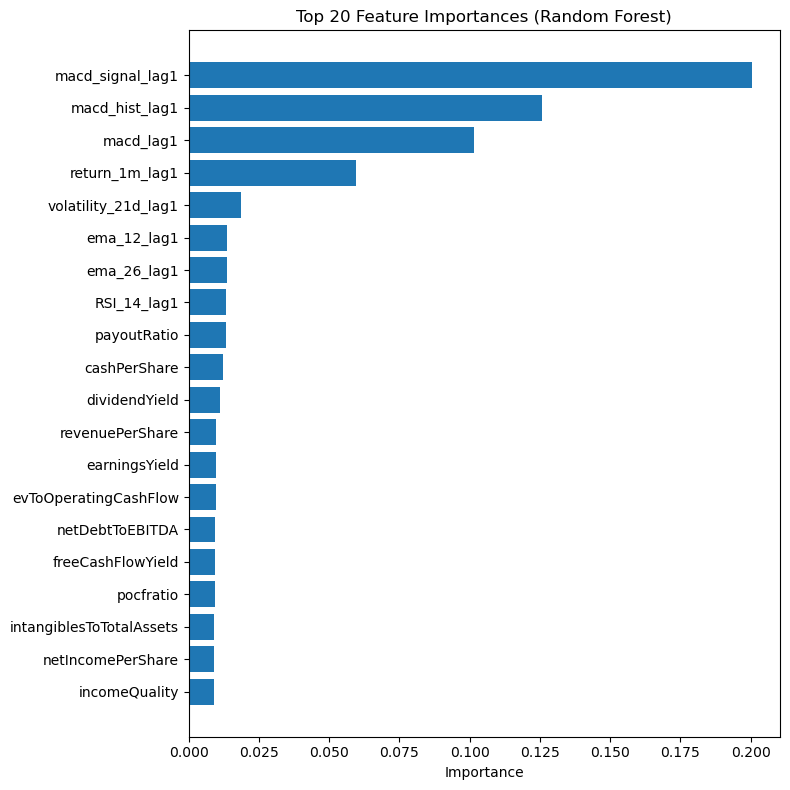

In [ ]:
#Baseline Model - include all features and let RF dropped less important features based on feature importance


# =====================================
# LOAD DATA
# =====================================
df = pd.read_parquet("./data/quantamental_cleaned.parquet")
sp500 = pd.read_csv("./data/sp500_index.csv")

df["date"] = pd.to_datetime(df["date"])
sp500["date"] = pd.to_datetime(sp500["date"])
df = df.sort_values(["symbol", "date"])
sp500 = sp500.sort_values("date")

# Merge S&P500 benchmark
sp500 = sp500.rename(columns={"close": "sp500_close"})
df = pd.merge(df, sp500[["date", "sp500_close"]], on="date", how="left")
df["sp500_return_1m"] = df["sp500_close"].pct_change(21)

# =====================================
# CREATE MONTHLY SNAPSHOT
# =====================================
df_monthly = (
    df.groupby(["symbol", pd.Grouper(key="date", freq="M")])
      .tail(1)
      .reset_index(drop=True)
)

# =====================================
# DEFINE FEATURES
# =====================================
technical_cols = [
    "return_1m","ema_12","ema_26","macd","macd_signal","macd_hist","RSI_14","volatility_21d"
]

fundamental_cols = [
    "revenuePerShare","netIncomePerShare","operatingCashFlowPerShare","freeCashFlowPerShare",
    "cashPerShare","bookValuePerShare","tangibleBookValuePerShare","shareholdersEquityPerShare",
    "interestDebtPerShare","marketCap","enterpriseValue","peRatio","priceToSalesRatio","pocfratio",
    "pfcfRatio","pbRatio","ptbRatio","evToSales","enterpriseValueOverEBITDA","evToOperatingCashFlow",
    "evToFreeCashFlow","earningsYield","freeCashFlowYield","debtToEquity","debtToAssets","netDebtToEBITDA",
    "currentRatio","interestCoverage","incomeQuality","dividendYield","payoutRatio",
    "salesGeneralAndAdministrativeToRevenue","researchAndDdevelopementToRevenue",
    "intangiblesToTotalAssets","capexToOperatingCashFlow","capexToRevenue","capexToDepreciation",
    "stockBasedCompensationToRevenue","grahamNumber","roic","returnOnTangibleAssets","grahamNetNet",
    "workingCapital","tangibleAssetValue","netCurrentAssetValue","investedCapital",
    "averageReceivables","averagePayables","averageInventory","daysSalesOutstanding",
    "daysPayablesOutstanding","daysOfInventoryOnHand","receivablesTurnover","payablesTurnover",
    "inventoryTurnover","roe","capexPerShare"
]

# Forward-fill fundamentals to handle quarterly updates
df_monthly[fundamental_cols] = df_monthly.groupby("symbol")[fundamental_cols].ffill()

# =====================================
# LABEL GENERATION
# =====================================
df_monthly["fwd_return_1m"] = df_monthly.groupby("symbol")["close"].shift(-1)/df_monthly["close"] - 1
df_monthly["fwd_sp500_return_1m"] = df_monthly["sp500_return_1m"].shift(-1)
df_monthly["label"] = (df_monthly["fwd_return_1m"] > df_monthly["fwd_sp500_return_1m"]).astype(int)

# =====================================
# LAG TECHNICALS TO AVOID LEAKAGE
# =====================================
for col in technical_cols:
    df_monthly[f"{col}_lag1"] = df_monthly.groupby("symbol")[col].shift(1)

feature_names = [f"{col}_lag1" for col in technical_cols] + fundamental_cols
df_model = df_monthly.dropna(subset=feature_names + ["label", "symbol"])

# =====================================
# TRAIN/TEST SPLIT (Sep 2024–Sep 2025 vs Oct 2025)
# =====================================
train_start, train_end = pd.Timestamp("2024-09-01"), pd.Timestamp("2025-09-30")
test_start, test_end = pd.Timestamp("2025-10-01"), pd.Timestamp("2025-10-31")

train_mask = (df_model["date"] >= train_start) & (df_model["date"] <= train_end)
test_mask  = (df_model["date"] >= test_start) & (df_model["date"] <= test_end)
df_train, df_test = df_model.loc[train_mask], df_model.loc[test_mask]

print(f"Train rows: {len(df_train)}, Test rows: {len(df_test)}")

# =====================================
# TRAIN MODEL
# =====================================
X_train, y_train = df_train[feature_names], df_train["label"]
X_test, y_test   = df_test[feature_names],  df_test["label"]

X_train = X_train.replace([np.inf, -np.inf], 0).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], 0).fillna(0)

scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=400, max_depth=8, random_state=42,class_weight="balanced")
rf.fit(X_train_s, y_train)

# =====================================
# EVALUATION
# =====================================
y_pred = rf.predict(X_test_s)
y_prob = rf.predict_proba(X_test_s)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)

print(f"\n=== Evaluation: Oct 2025 Test Month ===")
print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  AUC={auc:.3f}")

# =====================================
# FEATURE IMPORTANCE
# =====================================
importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

# Show top 25 most important features
print("\n=== Top 25 Feature Importances ===")
print(importances.head(25).round(4))

# Save all importances to CSV for later review
importances.to_csv("feature_importance_full.csv", index=False)

# Plot top 20
plt.figure(figsize=(8,8))
top_n = importances.head(20)
plt.barh(top_n["Feature"], top_n["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


We will only select features which are matter in this case and retrain model. Features name are included in the next step and retrain model


C:\Users\siris\AppData\Local\Temp\ipykernel_16940\2495753956.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["sp500_return_1m"] = df["sp500_close"].pct_change(21)
C:\Users\siris\AppData\Local\Temp\ipykernel_16940\2495753956.py:31: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(["symbol", pd.Grouper(key="date", freq="M")])


Train rows: 6539, Test rows: 503

=== Evaluation: Oct 2025 Test Month ===
Accuracy=0.738  Precision=0.554  Recall=0.734  AUC=0.834

=== Top 10 Predicted Outperformers for Oct 2025 ===
      symbol       date  pred_prob  label
15888    TER 2025-09-30      0.836      1
16070    TMO 2025-09-30      0.817      1
995      AMD 2025-09-30      0.813      1
9074     IQV 2025-09-30      0.809      1
5845     EME 2025-09-30      0.806      1
5808     ELV 2025-09-30      0.805      1
11964    MTD 2025-09-30      0.802      1
4751    DDOG 2025-09-30      0.797      1
4126     CRL 2025-09-30      0.776      1
12325    NOC 2025-09-30      0.771      0

=== Top 20 Feature Importances ===
                     Feature  Importance
4           macd_signal_lag1      0.2077
5             macd_hist_lag1      0.1379
3                  macd_lag1      0.1070
0             return_1m_lag1      0.0807
7        volatility_21d_lag1      0.0261
2                ema_26_lag1      0.0213
6                RSI_14_lag1   

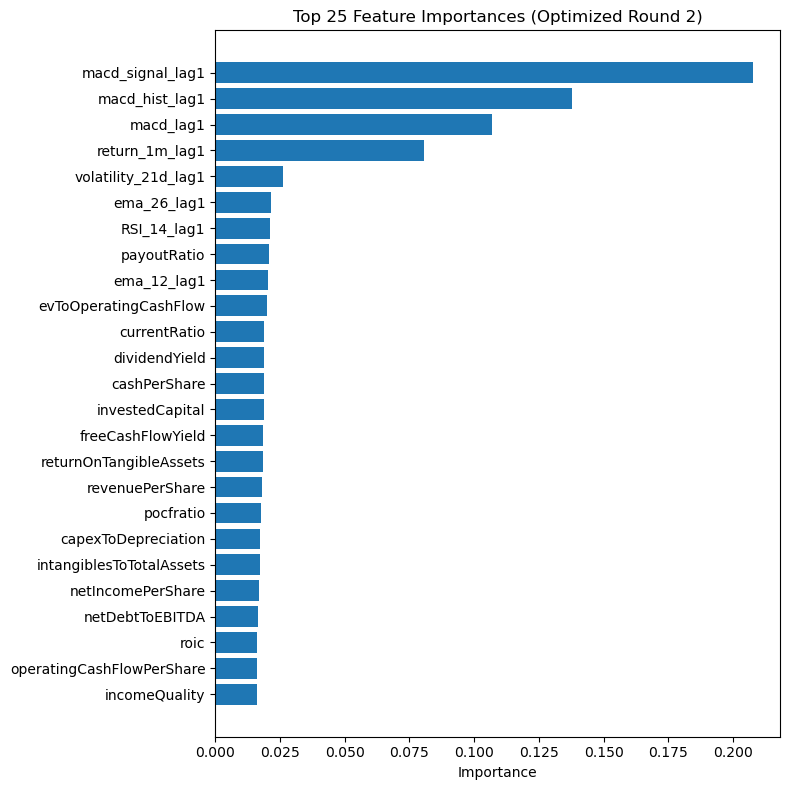

In [ ]:

# =====================================
# LOAD DATA (LATEST )
# =====================================
df = pd.read_parquet("./data/quantamental_cleaned.parquet")
sp500 = pd.read_csv("./data/sp500_index.csv")

df["date"] = pd.to_datetime(df["date"])
sp500["date"] = pd.to_datetime(sp500["date"])
df = df.sort_values(["symbol", "date"])
sp500 = sp500.sort_values("date")

# Merge S&P500 benchmark
sp500 = sp500.rename(columns={"close": "sp500_close"})
df = pd.merge(df, sp500[["date", "sp500_close"]], on="date", how="left")
df["sp500_return_1m"] = df["sp500_close"].pct_change(21)

# =====================================
# CREATE MONTHLY SNAPSHOT
# =====================================
df_monthly = (
    df.groupby(["symbol", pd.Grouper(key="date", freq="M")])
      .tail(1)
      .reset_index(drop=True)
)

# =====================================
# DEFINE FEATURE SETS  (based on previous step outcome)
# =====================================
technical_cols = [
    "return_1m","ema_12","ema_26","macd","macd_signal","macd_hist","RSI_14","volatility_21d"
]

fundamental_cols = [
    "payoutRatio","cashPerShare","dividendYield","revenuePerShare","earningsYield",
    "evToOperatingCashFlow","netDebtToEBITDA","freeCashFlowYield","pocfratio",
    "intangiblesToTotalAssets","netIncomePerShare","incomeQuality","capexToDepreciation",
    "operatingCashFlowPerShare","peRatio","returnOnTangibleAssets","investedCapital",
    # core additions ,we add this features as it is an important features for finance
    "roe","roic","debtToEquity","currentRatio","interestCoverage"
]

# =====================================
# CREATE LAGGED TECHNICAL FEATURES
# =====================================
for col in technical_cols:
    df_monthly[f"{col}_lag1"] = df_monthly.groupby("symbol")[col].shift(1)

lagged_tech_features = [f"{col}_lag1" for col in technical_cols]

# =====================================
# FORWARD-FILL FUNDAMENTALS
# =====================================
df_monthly[fundamental_cols] = df_monthly.groupby("symbol")[fundamental_cols].ffill()

# =====================================
# FINAL FEATURE LIST
# =====================================
feature_names = lagged_tech_features + fundamental_cols

# Drop rows missing any of the key features
df_monthly = df_monthly.dropna(subset=feature_names)

# =====================================
# CREATE LABEL
# =====================================
df_monthly["fwd_return_1m"] = df_monthly.groupby("symbol")["close"].shift(-1)/df_monthly["close"] - 1
df_monthly["fwd_sp500_return_1m"] = df_monthly["sp500_return_1m"].shift(-1)
df_monthly["label"] = (df_monthly["fwd_return_1m"] > df_monthly["fwd_sp500_return_1m"]).astype(int)

# =====================================
# TRAIN/TEST WINDOW (AUG 2024 → AUG 2025 train, Sep 2025 test)
# =====================================
train_start, train_end = pd.Timestamp("2024-08-01"), pd.Timestamp("2025-08-30")
test_start, test_end = pd.Timestamp("2025-09-01"), pd.Timestamp("2025-09-30")

train_mask = (df_monthly["date"] >= train_start) & (df_monthly["date"] <= train_end)
test_mask  = (df_monthly["date"] >= test_start) & (df_monthly["date"] <= test_end)
df_train, df_test = df_monthly.loc[train_mask], df_monthly.loc[test_mask]

print(f"Train rows: {len(df_train)}, Test rows: {len(df_test)}")

# =====================================
# PREPARE DATA
# =====================================
X_train, y_train = df_train[feature_names], df_train["label"]
X_test, y_test   = df_test[feature_names],  df_test["label"]

X_train = X_train.replace([np.inf, -np.inf], 0).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], 0).fillna(0)

scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

# =====================================
# TRAIN RANDOM FOREST (balanced)
# =====================================
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    class_weight="balanced_subsample",
    random_state=42
)
rf.fit(X_train_s, y_train)

# =====================================
# EVALUATE MODEL
# =====================================
y_pred = rf.predict(X_test_s)
y_prob = rf.predict_proba(X_test_s)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)

print(f"\n=== Evaluation: Oct 2025 Test Month ===")
print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  AUC={auc:.3f}")

# =====================================
# TOP-10 PREDICTED OUTPERFORMERS
# =====================================
df_test = df_test.copy()
df_test["pred_prob"] = y_prob
df_test["pred_label"] = y_pred

top10 = (
    df_test.sort_values("pred_prob", ascending=False)
            .head(10)[["symbol","date","pred_prob","label"]]
)
print("\n=== Top 10 Predicted Outperformers for Oct 2025 ===")
print(top10.round(3))

# =====================================
# FEATURE IMPORTANCE
# =====================================
importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\n=== Top 20 Feature Importances ===")
print(importances.head(20).round(4))

# =====================================
# VISUALIZE FEATURE IMPORTANCE
# =====================================
plt.figure(figsize=(8,8))
top_n = importances.head(25)
plt.barh(top_n["Feature"], top_n["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 25 Feature Importances (Optimized Round 2)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


This chart shows the top 25 most important features that the Random Forest model relied on to predict whether a stock would outperform or underperform the S&P 500.

From the results, technical indicators dominate — especially MACD Signal, MACD Histogram, and 1-month return, suggesting that short-term momentum and trend signals have the strongest influence on the model’s predictions.
Meanwhile, fundamental ratios such as payout ratio, current ratio, and cash per share contribute less but still provide long-term financial stability context for the model’s decisions.

In [19]:
print(df_train["label"].value_counts(normalize=True))


label
0    0.558036
1    0.441964
Name: proportion, dtype: float64


The outperform/underperform label are balanced

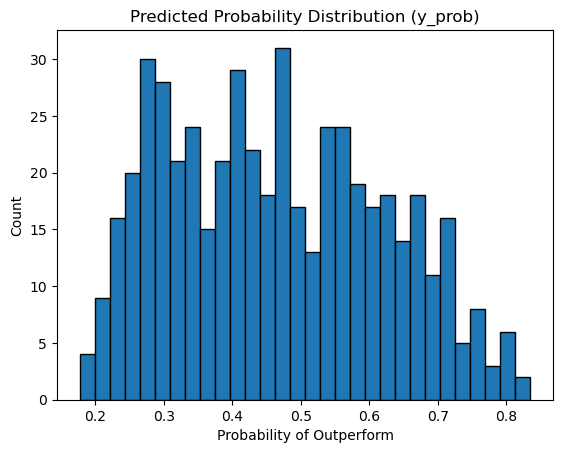

Min: 0.17679123774033978 Max: 0.8355379890323507 Mean: 0.46500765104964414


In [ ]:
#Display the predicted probability distribution

plt.hist(y_prob, bins=30, edgecolor='k')
plt.title("Predicted Probability Distribution (y_prob)")
plt.xlabel("Probability of Outperform")
plt.ylabel("Count")
plt.show()

print("Min:", y_prob.min(), "Max:", y_prob.max(), "Mean:", y_prob.mean())


This histogram shows the distribution of predicted probabilities from the Random Forest model — specifically, how confident the model is that each stock will outperform the S&P 500.

Most probabilities cluster around 0.3–0.6, meaning the model is generally uncertain and sees a roughly even balance between outperformers and underperformers.
The mean (~0.46) suggests that, on average, the model predicts a slightly higher chance of underperformance.

We use this plot to choose a cutoff threshold — for example, selecting a value (like 0.5 or one optimized for F1-score) that best separates likely outperformers (high probability) from likely underperformers (low probability). This threshold determines which stocks receive a “Buy” or “Avoid” signal in the final output.

We will repeat the step with the adjust cut off threshold based on this chart

C:\Users\siris\AppData\Local\Temp\ipykernel_16940\3902752184.py:26: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["sp500_return_1m"] = df["sp500_close"].pct_change(21)
C:\Users\siris\AppData\Local\Temp\ipykernel_16940\3902752184.py:32: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(["symbol", pd.Grouper(key="date", freq="M")])
C:\Users\siris\AppData\Local\Temp\ipykernel_16940\3902752184.py:65: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="date", freq="M"))["sp500_close"]



Label distribution (all data):
label
0    0.665
1    0.335
Name: proportion, dtype: float64
2023-10 | Thresh=0.319 | Acc=0.601 Prec=0.559 Rec=0.952 AUC=0.609
2023-11 | Thresh=0.598 | Acc=0.642 Prec=0.447 Rec=0.811 AUC=0.741
2024-01 | Thresh=0.564 | Acc=0.782 Prec=0.708 Rec=0.836 AUC=0.843
2024-02 | Thresh=0.516 | Acc=0.753 Prec=0.570 Rec=0.760 AUC=0.816
2024-04 | Thresh=0.405 | Acc=0.686 Prec=0.541 Rec=0.845 AUC=0.786
2024-05 | Thresh=0.440 | Acc=0.548 Prec=0.164 Rec=0.802 AUC=0.667
2024-07 | Thresh=0.275 | Acc=0.652 Prec=0.615 Rec=0.909 AUC=0.722


c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


2024-08 | Thresh=0.145 | Acc=0.002 Prec=0.000 Rec=0.000 AUC=nan
2024-09 | Thresh=0.430 | Acc=0.722 Prec=0.672 Rec=0.832 AUC=0.791
2024-10 | Thresh=0.345 | Acc=0.765 Prec=0.769 Rec=0.834 AUC=0.827


c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


2024-11 | Thresh=0.163 | Acc=0.002 Prec=0.000 Rec=0.000 AUC=nan
2024-12 | Thresh=0.291 | Acc=0.606 Prec=0.578 Rec=0.932 AUC=0.722
2025-01 | Thresh=0.405 | Acc=0.779 Prec=0.794 Rec=0.814 AUC=0.846
2025-02 | Thresh=0.250 | Acc=0.634 Prec=0.631 Rec=0.984 AUC=0.703
2025-03 | Thresh=0.396 | Acc=0.656 Prec=0.545 Rec=0.836 AUC=0.767
2025-04 | Thresh=0.539 | Acc=0.658 Prec=0.527 Rec=0.878 AUC=0.748


c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


2025-05 | Thresh=0.212 | Acc=0.002 Prec=0.000 Rec=0.000 AUC=nan
2025-06 | Thresh=0.462 | Acc=0.694 Prec=0.599 Rec=0.850 AUC=0.793
2025-07 | Thresh=0.267 | Acc=0.579 Prec=0.562 Rec=0.985 AUC=0.622


c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


2025-08 | Thresh=0.219 | Acc=0.002 Prec=0.000 Rec=0.000 AUC=nan
2025-09 | Thresh=0.480 | Acc=0.647 Prec=0.318 Rec=0.731 AUC=0.716

=== Rolling 12-Month Evaluation Summary ===
       Threshold  Accuracy  Precision  Recall     AUC
count     21.000    21.000     21.000  21.000  17.000
mean       0.368     0.543      0.457   0.695   0.748
std        0.133     0.276      0.265   0.351   0.071
min        0.145     0.002      0.000   0.000   0.609
25%        0.267     0.579      0.318   0.760   0.716
50%        0.396     0.647      0.559   0.834   0.748
75%        0.462     0.694      0.615   0.878   0.793
max        0.598     0.782      0.794   0.985   0.846

Top Feature Importance:
                 Feature  Importance
5        macd_hist_lag1      0.2459
4      macd_signal_lag1      0.1812
3             macd_lag1      0.0962
0        return_1m_lag1      0.0846
7   volatility_21d_lag1      0.0299
..                  ...         ...
2           ema_26_lag1      0.0132
6           RSI_14_lag1  

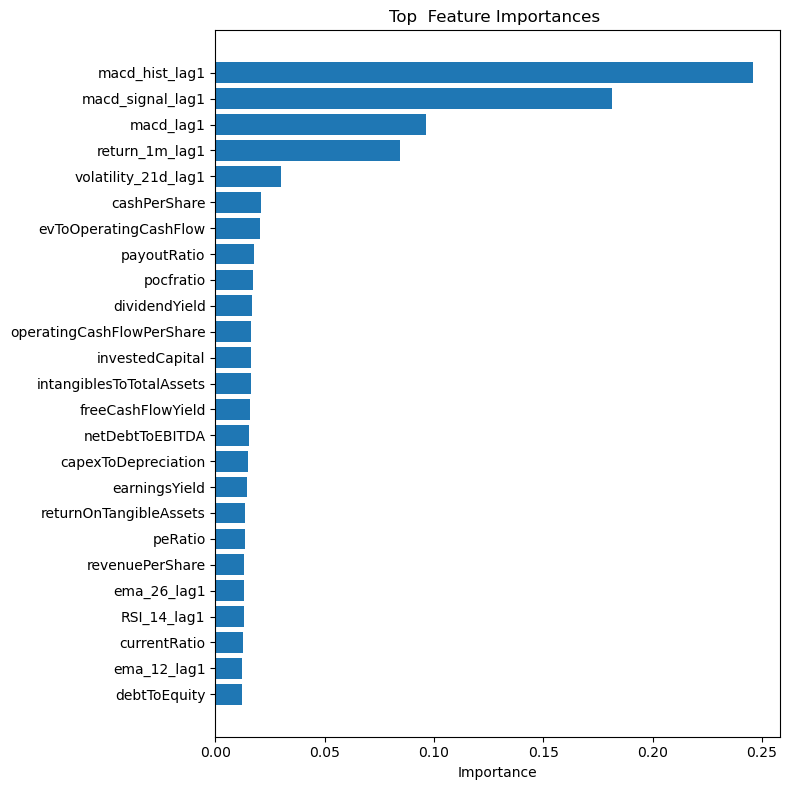

In [ ]:
# Adjust cut off threshold

# =====================================
# LOAD DATA
# =====================================
df = pd.read_parquet("./data/quantamental_cleaned.parquet")
sp500 = pd.read_csv("./data/sp500_index.csv")

df["date"] = pd.to_datetime(df["date"])
sp500["date"] = pd.to_datetime(sp500["date"])
df = df.sort_values(["symbol", "date"])
sp500 = sp500.sort_values("date")

# Merge S&P500 benchmark
sp500 = sp500.rename(columns={"close": "sp500_close"})
df = pd.merge(df, sp500[["date", "sp500_close"]], on="date", how="left")
df["sp500_return_1m"] = df["sp500_close"].pct_change(21)

# =====================================
# CREATE MONTHLY SNAPSHOT
# =====================================
df_monthly = (
    df.groupby(["symbol", pd.Grouper(key="date", freq="M")])
      .tail(1)
      .reset_index(drop=True)
)

# =====================================
# DEFINE FEATURE SETS
# =====================================
tech_cols = [
    "return_1m","ema_12","ema_26","macd","macd_signal","macd_hist","RSI_14","volatility_21d"
]

fund_cols = [
    "payoutRatio","cashPerShare","dividendYield","revenuePerShare","earningsYield",
    "evToOperatingCashFlow","netDebtToEBITDA","freeCashFlowYield","pocfratio",
    "intangiblesToTotalAssets","netIncomePerShare","incomeQuality","capexToDepreciation",
    "operatingCashFlowPerShare","peRatio","returnOnTangibleAssets","investedCapital",
    # core additions
    "roe","roic","debtToEquity","currentRatio","interestCoverage"
]

# Forward-fill fundamentals (quarterly)
#fund_cols = ["roe", "peRatio", "freeCashFlowYield", "debtToEquity", "currentRatio", "dividendYield"]
df_monthly[fund_cols] = df_monthly.groupby("symbol")[fund_cols].ffill()


# =====================================
# CREATE FORWARD-LOOKING LABEL
# (align S&P returns properly per month)
# =====================================

# 1️⃣ Compute S&P500 monthly closes (end-of-month)
spm = (
    df.groupby(pd.Grouper(key="date", freq="M"))["sp500_close"]
      .last()
      .reset_index()
      .rename(columns={"sp500_close": "sp500_close_curr"})
)
spm["sp500_close_next"] = spm["sp500_close_curr"].shift(-1)
spm["fwd_sp500_return_1m"] = spm["sp500_close_next"] / spm["sp500_close_curr"] - 1

# 2️⃣ Merge monthly S&P forward return back into df_monthly
df_monthly = df_monthly.merge(
    spm[["date", "fwd_sp500_return_1m"]],
    on="date", how="left"
)

# 3️⃣ Compute stock forward return aligned by symbol
df_monthly["fwd_return_1m"] = (
    df_monthly.groupby("symbol")["close"].shift(-1) / df_monthly["close"] - 1
)

# 4️⃣ Label: 1 if stock beats S&P next month
df_monthly["label"] = (
    df_monthly["fwd_return_1m"] > df_monthly["fwd_sp500_return_1m"]
).astype(int)

# ✅ Check label balance
print("\nLabel distribution (all data):")
print(df_monthly["label"].value_counts(normalize=True).round(3))





# =====================================
# LAG TECHNICAL INDICATORS (prevent leakage)
# =====================================
#tech_cols = ["return_1m", "macd_hist", "RSI_14", "volatility_21d"]
for col in tech_cols:
    df_monthly[f"{col}_lag1"] = df_monthly.groupby("symbol")[col].shift(1)

# =====================================
# FINAL FEATURE SET
# =====================================
feature_names = [f"{col}_lag1" for col in tech_cols] + fund_cols
df_model = df_monthly.dropna(subset=feature_names + ["label"])

# =====================================
# ROLLING 12-MONTH TRAIN/TEST LOOP
# =====================================
all_results = []

start_date = df_model["date"].min() + relativedelta(months=11)
end_date = df_model["date"].max()



while start_date < end_date:
    # Define rolling window (11M train + 1M test)
    train_start = start_date - relativedelta(months=11)
    train_end = start_date
    test_start = start_date
    test_end = start_date + relativedelta(months=1)

    train_mask = (df_model["date"] >= train_start) & (df_model["date"] < train_end)
    test_mask = (df_model["date"] >= test_start) & (df_model["date"] < test_end)

    df_train = df_model.loc[train_mask]
    df_test = df_model.loc[test_mask]

    if len(df_train) < 100 or len(df_test) < 10:
        start_date += relativedelta(months=1)
        continue

    X_train, y_train = df_train[feature_names], df_train["label"]
    X_test, y_test = df_test[feature_names], df_test["label"]

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model (with class balancing)
    rf = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced", random_state=42)
    rf.fit(X_train_scaled, y_train)

    # Predict probabilities
    y_prob = rf.predict_proba(X_test_scaled)[:, 1]

    # =====================================
    # AUTO-THRESHOLD USING F1 OPTIMIZATION
    # =====================================
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx] if len(thresholds) > 0 else 0.5

    y_pred = (y_prob > best_thresh).astype(int)

    # Evaluate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    all_results.append({
        "Test_Month": test_start.strftime("%Y-%m"),
        "Train_Start": train_start.strftime("%Y-%m"),
        "Train_End": train_end.strftime("%Y-%m"),
        "Threshold": round(best_thresh, 3),
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "AUC": round(auc, 3)
    })

    print(f"{test_start:%Y-%m} | Thresh={best_thresh:.3f} | Acc={acc:.3f} Prec={prec:.3f} Rec={rec:.3f} AUC={auc:.3f}")

    start_date += relativedelta(months=1)

# =====================================
# SUMMARY OF ROLLING RESULTS
# =====================================
results_df = pd.DataFrame(all_results)
print("\n=== Rolling 12-Month Evaluation Summary ===")
print(results_df.describe().round(3))

# =====================================
# FEATURE IMPORTANCE (last model)
# =====================================
importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop Feature Importance:\n", importances.head(25).round(4))


# =====================================
# VISUALIZE FEATURE IMPORTANCE
# =====================================
plt.figure(figsize=(8,8))
top_n = importances.head(25)
plt.barh(top_n["Feature"], top_n["Importance"])
plt.gca().invert_yaxis()
plt.title("Top  Feature Importances ")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()



In [40]:
# =====================================
# FINAL MODEL: PREDICT LAST MONTH FOR TESTING 
# =====================================
print("\n=== Final Quantamental Prediction: october 2025 ===")

# 1️⃣ Define training and test windows
test_month = pd.Timestamp("2025-09-01")
train_start = test_month - relativedelta(months=12)
train_end = test_month - relativedelta(days=1)

df_train = df_model[(df_model["date"] >= train_start) & (df_model["date"] < train_end)]
df_test  = df_model[(df_model["date"].dt.to_period("M") == test_month.to_period("M"))]

if len(df_test) == 0:
    print("No data for Oct 2025.")
else:
    # 2️⃣ Prepare features
    X_train, y_train = df_train[feature_names], df_train["label"]
    X_test = df_test[feature_names]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3️⃣ Train model
    rf_final = RandomForestClassifier(n_estimators=400, max_depth=8, class_weight="balanced", random_state=42)
    rf_final.fit(X_train_scaled, y_train)

    # 4️⃣ Predict probabilities
    y_prob = rf_final.predict_proba(X_test_scaled)[:, 1]

    # 5️⃣ Find optimal F1 threshold
    from sklearn.metrics import precision_recall_curve

    y_val_prob = rf_final.predict_proba(X_train_scaled)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_train, y_val_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx] if len(thresholds) > 0 else 0.5

    y_pred = (y_prob > best_thresh).astype(int)

    # 6️⃣ Attach predictions to DataFrame
    df_test["pred_prob"] = y_prob
    df_test["pred_label"] = y_pred

    # 7️⃣ Rank Top 10 Outperformers
    top10 = df_test.sort_values("pred_prob", ascending=False).head(10)[["symbol", "date", "pred_prob", "label"]]
    print("\nTop 10 predicted outperformers for Oct 2025:")
    print(top10.to_string(index=False))

    # 8️⃣ Summary metrics
    acc  = accuracy_score(df_test["label"], df_test["pred_label"])
    prec = precision_score(df_test["label"], df_test["pred_label"], zero_division=0)
    rec  = recall_score(df_test["label"], df_test["pred_label"], zero_division=0)
    auc  = roc_auc_score(df_test["label"], df_test["pred_prob"])
    print(f"\nOct 2025 Metrics | Thresh={best_thresh:.3f} | Acc={acc:.3f} Prec={prec:.3f} Rec={rec:.3f} AUC={auc:.3f}")

    # 9️⃣ Save to CSV (optional)
    output_path = "./results_oct2025_predictions.csv"
    df_test[["symbol", "date", "pred_prob", "pred_label", "label"]].to_csv(output_path, index=False)
    print(f"\nPredictions saved to {output_path}")



=== Final Quantamental Prediction: october 2025 ===

Top 10 predicted outperformers for Oct 2025:
symbol       date  pred_prob  label
   NOC 2025-09-30   0.791697      0
   IQV 2025-09-30   0.786264      1
   AXP 2025-09-30   0.784225      1
   ELV 2025-09-30   0.783598      1
   TMO 2025-09-30   0.781857      1
   RTX 2025-09-30   0.770872      1
   EME 2025-09-30   0.770345      1
   CRL 2025-09-30   0.770107      1
     J 2025-09-30   0.766848      1
  VRTX 2025-09-30   0.766682      1

Oct 2025 Metrics | Thresh=0.468 | Acc=0.750 Prec=0.657 Rec=0.725 AUC=0.795

Predictions saved to ./results_oct2025_predictions.csv


C:\Users\siris\AppData\Local\Temp\ipykernel_16940\3760589232.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["pred_prob"] = y_prob
C:\Users\siris\AppData\Local\Temp\ipykernel_16940\3760589232.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["pred_label"] = y_pred


## Predict the next future month

This code uses the most recent 12 months of data (Oct 2024–Oct 2025) to train a Random Forest model, then predicts which stocks are likely to outperform in November 2025 — even though the real outcomes (ground truth) are not yet known.

It scales the features, trains the model, and outputs each stock’s probability of outperforming the S&P 500 next month.
The results are ranked by predicted probability, and the Top 10 highest-ranked stocks are listed as the most likely outperformers for November 2025.

**Step Description :**

1️	Train on the last 12 months of known history

2️	Use October 2025 features (latest available)

3️	Predict which stocks will beat S&P in November 2025

4️	Generate a ranked list of buy candidates (pred_prob_next_month)

5️	No accuracy/recall computed — because ground truth isn’t available yet

In [ ]:



print("\n=== PREDICTING NEXT MONTH (Nov 2025, no ground truth yet) ===")

# Define windows
predict_month = pd.Timestamp("2025-11-01")
train_start = predict_month - relativedelta(months=12)
train_end = predict_month - relativedelta(days=1)

# Train on previous 12 months (Oct 2024–Oct 2025)
df_train = df_model[(df_model["date"] >= train_start) & (df_model["date"] <= train_end)]

# Predict for current/latest available month (Oct 2025 features)
df_predict = df_model[df_model["date"].dt.to_period("M") == pd.Period("2025-10")].copy()

# Prepare data
X_train = df_train[feature_names]
y_train = df_train["label"]
X_pred = df_predict[feature_names]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_pred_scaled = scaler.transform(X_pred)

# Train model
rf_deploy = RandomForestClassifier(
    n_estimators=400, max_depth=8, class_weight="balanced", random_state=42
)
rf_deploy.fit(X_train_scaled, y_train)

# Predict probability of outperforming
pred_prob = rf_deploy.predict_proba(X_pred_scaled)[:, 1]

df_predict["pred_prob_next_month"] = pred_prob
df_predict["pred_rank"] = df_predict["pred_prob_next_month"].rank(ascending=False)

# Rank top 10 expected outperformers for November 2025
top10_next = df_predict.sort_values("pred_prob_next_month", ascending=False).head(10)[
    ["symbol", "date", "pred_prob_next_month"]
]
print("\nTop 10 Predicted Outperformers for November 2025 (No Ground Truth):")
print(top10_next.to_string(index=False))

# Optional: save
df_predict[["symbol", "date", "pred_prob_next_month", "pred_rank"]].to_csv(
    "./predictions_nov2025.csv", index=False
)
print("\nPredictions saved to ./predictions_nov2025.csv")



=== PREDICTING NEXT MONTH (Nov 2025, no ground truth yet) ===

Top 10 Predicted Outperformers for November 2025 (No Ground Truth):
symbol       date  pred_prob_next_month
   EIX 2025-10-24              0.503551
  ISRG 2025-10-24              0.496757
    GM 2025-10-24              0.488427
  KLAC 2025-10-24              0.487016
   HCA 2025-10-24              0.484896
   TDG 2025-10-24              0.480334
   RTX 2025-10-24              0.479758
   AXP 2025-10-24              0.465362
    PH 2025-10-24              0.464108
   DOV 2025-10-24              0.450966

Predictions saved to ./predictions_nov2025.csv


This code below converts the model’s predicted probabilities into trading signals for November 2025.

Stocks with a predicted probability above 0.40 are labeled “LONG-Outperform” (buy signal).

Stocks with a probability below 0.35 are labeled “SHORT-Underperform” (sell or avoid signal).

Others are marked as “NEUTRAL.”

It then sorts all predictions from highest to lowest probability, displays the top 5 long and short candidates, and saves the full list (with signals and probabilities) to signals_nov2025.csv for portfolio or dashboard use.

In [ ]:
# =====================================
# SIGNAL GENERATION (LONG (buy) / SHORT)
# =====================================
prod_threshold = 0.40  # or results_df["Threshold"].mean() if already defined

df_predict["signal"] = np.where(
    df_predict["pred_prob_next_month"] > prod_threshold, "LONG-Outperform",
    np.where(df_predict["pred_prob_next_month"] < (prod_threshold - 0.05), "SHORT-Underperform", "NEUTRAL")
)

# Sort full dataframe by probability (high → low)
df_predict = df_predict.sort_values("pred_prob_next_month", ascending=False).reset_index(drop=True)

# Show distribution of signals
print("\nSignal Distribution:")
print(df_predict["signal"].value_counts())

# Display Top N LONG and SHORT signals
top_long = df_predict[df_predict["signal"] == "LONG-Outperform"].head(5)
top_short = df_predict[df_predict["signal"] == "SHORT-Underperform"].tail(5)  # tail since low probs now at bottom

print("\n=== Top 5 LONG (Buy) Signals for Nov 2025 ===")
print(top_long[["symbol", "pred_prob_next_month","signal"]])

print("\n=== Top 5 SHORT (Sell/Avoid) Signals for Nov 2025 ===")
print(top_short[["symbol", "pred_prob_next_month","signal"]])

# Save for dashboard/portfolio (sorted by probability)
output_path = "./signals_nov2025.csv"
df_predict[["symbol", "date", "pred_prob_next_month", "signal"]].to_csv(output_path, index=False)
print(f"\nSignals saved (sorted high→low) to {output_path}")



Signal Distribution:
signal
SHORT-Underperform    428
NEUTRAL                47
LONG-Outperform        28
Name: count, dtype: int64

=== Top 5 LONG (Buy) Signals for Nov 2025 ===
  symbol  pred_prob_next_month           signal
0    EIX              0.503551  LONG-Outperform
1   ISRG              0.496757  LONG-Outperform
2     GM              0.488427  LONG-Outperform
3   KLAC              0.487016  LONG-Outperform
4    HCA              0.484896  LONG-Outperform

=== Top 5 SHORT (Sell/Avoid) Signals for Nov 2025 ===
    symbol  pred_prob_next_month              signal
498    NVR              0.103725  SHORT-Underperform
499    RJF              0.099771  SHORT-Underperform
500    BLK              0.099422  SHORT-Underperform
501    PKG              0.097557  SHORT-Underperform
502     GL              0.093575  SHORT-Underperform

Signals saved (sorted high→low) to ./signals_nov2025.csv


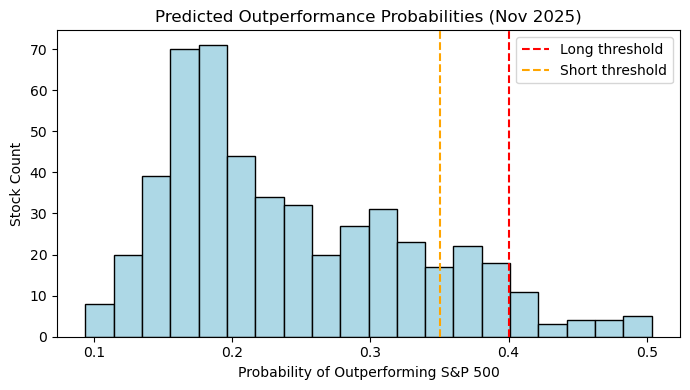

In [25]:
plt.figure(figsize=(7,4))
plt.hist(df_predict["pred_prob_next_month"], bins=20, color='lightblue', edgecolor='k')
plt.axvline(prod_threshold, color='red', linestyle='--', label='Long threshold')
plt.axvline(prod_threshold - 0.05, color='orange', linestyle='--', label='Short threshold')
plt.title("Predicted Outperformance Probabilities (Nov 2025)")
plt.xlabel("Probability of Outperforming S&P 500")
plt.ylabel("Stock Count")
plt.legend()
plt.tight_layout()
plt.show()


**Strategy Mapping - Signal	Interpretation	 Action**

**LONG**	Model believes the stock will outperform S&P500 next month	Add to buy list or overweight

**NEUTRAL**	No strong conviction	Hold or ignore

**SHORT**	Model expects underperformance	Avoid / hedge / underweight

## Create Hybrid score

###  Why We Need a Hybrid Quantamental Score

In stock analysis, there are two main perspectives:

| Perspective | Focus | Limitation |
|--------------|--------|-------------|
| **Fundamental Analysis** | Measures a company’s real business strength — profits, debt, cash flow, valuation, etc. | Changes slowly and may miss short-term market signals |
| **Technical Analysis** | Measures market sentiment and price momentum — how traders are behaving right now | Ignores company fundamentals and can overreact to noise |

A **Hybrid Quantamental Score** combines both perspectives into one interpretable measure.  
This approach is called *quantamental investing*, meaning **quantitative + fundamental** —  
using data-driven signals to evaluate both company strength and market behavior at once.

We use this score incorporate with the outcome of stock signal prediction in order to help user making decision. Long Term user should rely more on the quality of the company which reflects in the Fundamental Analysis. Short term user benefits more on Technical Analysis and the outcome of the Random forest classifier output. 

---

##  Purpose of Fundamental and Technical Scores

- **Fundamental Score** → tells us how financially strong or undervalued a company is  
  (based on metrics like ROE, PE Ratio, Free Cash Flow Yield, Debt/Equity, etc.)

- **Technical Score** → tells us how the stock is performing in the market  
  (based on metrics like MACD, RSI, Monthly Return, and Volatility)

By calculating both, we can:
- Identify **quality companies** (good fundamentals)
- That also show **positive market momentum** (good technicals)

These are often the most promising stocks — “**good companies getting better.**”

---

##  What the Code Does

This section of the notebook calculates three new scores for each stock:

1. **Fundamental_Score**
   - Uses financial ratios such as ROE, PE Ratio, Free Cash Flow Yield, Debt to Equity, and more.
   - Each feature is **normalized between 0 and 1** using Min–Max scaling, so they are comparable.
   - Features where **lower is better** (like PE or Debt/Equity) are **inverted** first,  
     so that higher values always mean better performance.
   - Then we take the **average of all normalized fundamental features** to get a single score per stock.

2. **Technical_Score**
   - Uses indicators such as monthly return, MACD, RSI, and volatility.
   - Also normalized to 0–1 so that all features contribute equally.
   - Volatility is inverted so that **lower volatility = higher technical score**.
   - Then we average them to get a single technical momentum score.

3. **Hybrid_Score**
   - Combines both scores:
     \[
     \text{Hybrid\_Score} = 0.5 \times \text{Fundamental\_Score} + 0.5 \times \text{Technical\_Score}
     \]
   - It is possible to adjust the weights:
     - More **short-term focus** → 70% technical, 30% fundamental  
     - More **long-term focus** → 70% fundamental, 30% technical

4. **Hybrid_Rank**
   - Within each month, all stocks are ranked by Hybrid_Score (1 = best performer for that month).
   - This gives a monthly leaderboard of the strongest “quantamental” stocks.

---

##  Summary of What Happens in Code

1. Clean and prepare the data (`NaN`, `inf`, zero replacement).  
2. Invert downside metrics (e.g., 1 / PE Ratio, 1 / Volatility).  
3. Normalize all factors using **Min–Max scaling (0–1)**.  
4. Calculate:
   - `Technical_Score` = average of normalized technical indicators  
   - `Fundamental_Score` = average of normalized fundamental indicators  
   - `Hybrid_Score` = weighted combination of both
5. Rank all stocks each month by their `Hybrid_Score`.
6. Sort and display the top-ranked stocks with the strongest fundamentals *and* momentum.

---

##  Why This Matters

This Hybrid Quantamental Score serves three purposes:
- Makes model results easier to interpret (we can explain “why” a stock scores high)
- Can be used alongside Random Forest predictions to build a combined “AI Quant Score”
- Creates a consistent ranking system for both short-term trading and long-term investing

In short:
> **The Hybrid Score bridges financial health (fundamentals) and market behavior (technicals), giving a complete 360° view of stock strength.**


##  Quantamental Feature Reference Table

This table explains each **technical** and **fundamental** factor used in the Quantamental and Hybrid Score model.  
Each feature captures a specific dimension of company performance or market sentiment.  
Together, they help evaluate whether a stock is fundamentally strong and/or technically bullish.

---

###  Technical Indicators (Market Momentum & Price Action)

| Feature | Description | Used For | Typical Signal | Interpretation |
|----------|--------------|-----------|----------------|----------------|
| **return_1m** | 1-month percentage return of the stock. Measures short-term momentum. | Short-term trading | ↑ High return → **Bullish / Buy**<br>↓ Negative → **Bearish / Sell** | Captures recent strength or weakness vs. S&P500. |
| **ema_12 / ema_26** | 12-day and 26-day *Exponential Moving Averages*. EMA_12 reacts faster than EMA_26. | Short- & mid-term | EMA_12 > EMA_26 → **Bullish**<br>EMA_12 < EMA_26 → **Bearish** | Used to spot trend direction. |
| **macd** | Difference between EMA_12 and EMA_26. Shows momentum strength. | Short-term | ↑ MACD rising → **Bullish**<br>↓ Falling → **Bearish** | Measures acceleration of price trend. |
| **macd_signal** | 9-day EMA of MACD. Used to identify MACD crossovers. | Short-term | MACD > Signal → **Buy**<br>MACD < Signal → **Sell** | Confirms bullish or bearish momentum. |
| **macd_hist** | MACD – MACD Signal. Shows divergence between short-term and mid-term trend. | Short-term | Positive hist → **Bullish**<br>Negative → **Bearish** | Momentum confirmation tool. |
| **RSI_14** | *Relative Strength Index* over 14 days. Measures speed and magnitude of price changes. | Short-term | RSI > 70 → **Overbought / Sell**<br>RSI < 30 → **Oversold / Buy** | Tracks market sentiment extremes. |
| **volatility_21d** | Standard deviation of daily returns over 21 days. Measures risk. | Short-term risk control | ↓ Low volatility → **Stable / Hold**<br>↑ High → **Risky / Sell** | High volatility may indicate uncertainty. |

**Summary:**  
Technical indicators are more relevant for **short-term (1–3 months)** momentum.  
High MACD, positive return_1m, and rising EMAs indicate **bullish** momentum;  
falling RSI and negative MACD suggest **bearish** or weak momentum.

---

###  Fundamental Factors (Financial Quality & Valuation)

| Feature | Description | Used For | Typical Signal | Interpretation |
|----------|--------------|-----------|----------------|----------------|
| **roe (Return on Equity)** | Profitability per unit of shareholder equity. | Long-term | ↑ High → **Buy / Strong fundamentals** | Measures management efficiency. |
| **roic (Return on Invested Capital)** | Profitability after considering debt & equity. | Long-term | ↑ High → **Buy** | Strong indicator of sustainable profitability. |
| **peRatio (Price-to-Earnings)** | How much investors pay per $1 of earnings. | Long-term valuation | ↓ Low → **Value / Buy**<br>↑ High → **Overvalued / Sell** | Measures valuation attractiveness. |
| **payoutRatio** | Portion of earnings paid as dividends. | Long-term | ↑ Moderate → **Stable / Hold**<br>Too high → **Risky / Sell** | Indicates sustainability of dividends. |
| **dividendYield** | Dividend return as % of stock price. | Long-term income | ↑ High → **Income Buy**<br>0 → **Growth stock / Neutral** | Steady dividends suggest mature, stable company. |
| **freeCashFlowYield** | Free cash flow relative to market cap. | Long-term | ↑ High → **Buy** | Reflects real cash profitability. |
| **operatingCashFlowPerShare** | Operating cash generated per share. | Long-term | ↑ High → **Buy / Strong quality** | Indicates cash-generating power. |
| **revenuePerShare** | Revenue per share, a measure of sales productivity. | Long-term growth | ↑ High or growing → **Buy** | Shows scale and demand strength. |
| **earningsYield** | Inverse of PE ratio. | Long-term valuation | ↑ High → **Undervalued / Buy** | Measures earnings return per dollar invested. |
| **debtToEquity** | Financial leverage ratio. | Long-term risk | ↓ Low → **Healthy / Buy**<br>↑ High → **Risky / Sell** | Captures balance sheet risk. |
| **currentRatio** | Current assets ÷ current liabilities. | Long-term liquidity | 1–2 → **Healthy**<br><1 → **Risky** | Indicates short-term solvency. |
| **interestCoverage** | EBIT (Earning before interest/tax) ÷ Interest expense. | Long-term risk | ↑ High → **Safe / Buy**<br>↓ Low → **Debt concern** | Shows ability to service debt. |
| **netDebtToEBITDA** | Debt relative to earnings capacity. | Long-term leverage | ↓ Low → **Safe**<br>↑ High → **Risky** | Used by credit analysts for leverage. |
| **intangiblesToTotalAssets** | Intangibles / total assets. | Long-term stability | ↓ Low → **Stable**<br>↑ High → **Risky** | High values imply weaker tangible asset base. |
| **pocfratio (Price / Operating Cash Flow)** | Valuation ratio alternative to PE. | Long-term valuation | ↓ Low → **Value Buy** | Cash-based valuation metric. |
| **capexToDepreciation** | Measures reinvestment vs asset wear. | Long-term growth | ↑ High → **Growth / Reinvestment** | Indicates investment intensity. |
| **cashPerShare** | Cash holdings per share. | Short-term defense | ↑ High → **Safe** | Provides cushion during downturns. |
| **incomeQuality** | Operating cash flow / Net income. | Long-term quality | ↑ High → **High-quality earnings** | Detects earnings manipulation risk. |
| **evToOperatingCashFlow** | Enterprise value / operating cash flow. | Long-term valuation | ↓ Low → **Value Buy** | Indicates how expensive a stock is relative to its cash flow. |
| **investedCapital** | Total long-term capital used by the firm. | Long-term structural | — | Used in ROIC computation context. |

**Summary:**  
Fundamental indicators describe **long-term health, valuation, and profitability**.  
They’re better suited for investors who hold positions for **6–24 months or longer**.

---



##  Investment Recommendation Based on Hybrid Quantamental Score

### Quantamental Hybrid Scoring Logic (Cross-Sectional Rank Method)

###  Purpose :
Combine **Fundamental** (long-term company strength) and **Technical** (short-term momentum) signals  
into a single, balanced score for smarter and more explainable stock screening.  This is added to compliment the prediction from Random Forest Classification

---

###  How It Works :

1. **Feature Groups**
   - **Technical:** short-term market behavior  
     → `return_1m`, `MACD`, `RSI_14`, `volatility_21d`, `EMA_12`, `EMA_26`
   - **Fundamental:** long-term financial health  
     → `ROE`, `ROIC`, `PE`, `Debt/Equity`, `Free Cash Flow Yield`, `Revenue/Share`

2. **Monthly Normalization**
   - Each feature is ranked **within its month** on a 0–1 percentile scale.  
   - Ensures fair, relative comparison among stocks (removes scale bias).

3. **Subscores**
   - `Technical_Score` = average of all technical feature ranks  
   - `Fundamental_Score` = average of all fundamental feature ranks  

4. **Hybrid Score**
   \[
   \text{Hybrid\_Score} = 0.5 \times \text{Fundamental\_Score} + 0.5 \times \text{Technical\_Score}
   \]

5. **Percentile-Based Classification**
   | Hybrid Percentile | Meaning |
   |--------------------|----------|
   | Top 30% | **Strong (Buy)** |
   | Middle 40% | **Neutral / Hold** |
   | Bottom 30% | **Weak (Avoid)** |

6. **Investment Bias**
   | Logic | Recommendation |
   |--------|----------------|
   | `Technical > Fundamental + 0.05` | 🔵 **Short-Term Buy (Momentum)** |
   | `Fundamental > Technical + 0.05` | 🟢 **Long-Term Buy (Fundamental)** |
   | Similar Strength | 🟡 **Balanced Buy / Hold** |
   | Low Hybrid Score | 🔴 **Avoid / Bearish** |

---

###  Why we think it Works
- **Dynamic:** adjusts every month, highlighting new leaders and laggards  
- **Explainable:** shows *why* a stock is favored (momentum vs fundamentals)  
- **Balanced:** supports both **short-term trading** and **long-term investing**

*** Need to back test and fine tune the threshold in the future ***


In [26]:

# ===========================================
#  HYBRID QUANTAMENTAL SCORE Calculation
# ===========================================

df_score = df_monthly.copy()
df_score.replace([np.inf, -np.inf], np.nan, inplace=True)

#  Define feature groups
tech_cols = [
    "return_1m","ema_12","ema_26","macd","macd_signal","macd_hist","RSI_14","volatility_21d"
]
fund_cols = [
    "payoutRatio","cashPerShare","dividendYield","revenuePerShare","earningsYield",
    "evToOperatingCashFlow","netDebtToEBITDA","freeCashFlowYield","pocfratio",
    "intangiblesToTotalAssets","netIncomePerShare","incomeQuality","capexToDepreciation",
    "operatingCashFlowPerShare","peRatio","returnOnTangibleAssets","investedCapital",
    "roe","roic","debtToEquity","currentRatio","interestCoverage"
]

# only use columns that exist in your data
tech_cols = [c for c in tech_cols if c in df_score.columns]
fund_cols = [c for c in fund_cols if c in df_score.columns]

#  Define if higher values are better (True) or worse (False)
higher_better = {
    # Technicals
    "return_1m": True, "ema_12": True, "ema_26": True,
    "macd": True, "macd_signal": True, "macd_hist": True,
    "RSI_14": True,  # can flip to False if you want high RSI = overbought
    "volatility_21d": False,
    # Fundamentals
    "payoutRatio": False,
    "cashPerShare": True,
    "dividendYield": True,
    "revenuePerShare": True,
    "earningsYield": True,
    "evToOperatingCashFlow": False,
    "netDebtToEBITDA": False,
    "freeCashFlowYield": True,
    "pocfratio": False,
    "intangiblesToTotalAssets": False,
    "netIncomePerShare": True,
    "incomeQuality": True,
    "capexToDepreciation": True,
    "operatingCashFlowPerShare": True,
    "peRatio": False,
    "returnOnTangibleAssets": True,
    "investedCapital": True,
    "roe": True,
    "roic": True,
    "debtToEquity": False,
    "currentRatio": True,
    "interestCoverage": True,
}

#  Prepare month identifier
df_score["ym"] = df_score["date"].dt.to_period("M")

#  Cross-sectional percentile ranks per month
def cs_rank(series, ascending):
    """Return percentile rank in [0,1]."""
    return series.rank(pct=True, ascending=ascending)

# Rank Technicals
for col in tech_cols:
    asc = not higher_better.get(col, True)  # ascending=True if lower is better
    df_score[f"{col}_rank"] = (
        df_score.groupby("ym")[col]
        .transform(lambda s: cs_rank(s, ascending=asc))
        .astype(float)
    )

# Rank Fundamentals
for col in fund_cols:
    asc = not higher_better.get(col, True)
    df_score[f"{col}_rank"] = (
        df_score.groupby("ym")[col]
        .transform(lambda s: cs_rank(s, ascending=asc))
        .astype(float)
    )

#  Compute Subscores
tech_rank_cols = [f"{c}_rank" for c in tech_cols]
fund_rank_cols = [f"{c}_rank" for c in fund_cols]

df_score["Technical_Score"] = df_score[tech_rank_cols].mean(axis=1, skipna=True)
df_score["Fundamental_Score"] = df_score[fund_rank_cols].mean(axis=1, skipna=True)
df_score["Hybrid_Score"] = 0.5 * df_score["Fundamental_Score"] + 0.5 * df_score["Technical_Score"]

#  Compute cross-sectional percentile of Hybrid_Score each month
df_score["Hybrid_CS_Pct"] = (
    df_score.groupby("ym")["Hybrid_Score"].transform(lambda s: s.rank(pct=True))
)

#  Generate Recommendation Labels
def classify_stock(row, top_cut=0.70, bot_cut=0.30, diff_thresh=0.05):
    hyb = row["Hybrid_CS_Pct"]
    diff = row["Technical_Score"] - row["Fundamental_Score"]
    if hyb >= top_cut:
        if diff > diff_thresh:
            return "Short-Term Buy (Momentum)"
        elif diff < -diff_thresh:
            return "Long-Term Buy (Fundamental)"
        else:
            return "Balanced Buy / Hold"
    elif hyb <= bot_cut:
        return "Avoid / Bearish"
    else:
        return "Hold / Neutral"

df_score["H_Score Recommendation"] = df_score.apply(classify_stock, axis=1)

#  Sort and rank for latest month
latest_month = df_score["ym"].max()
df_latest = (
    df_score[df_score["ym"] == latest_month]
    .sort_values("Hybrid_Score", ascending=False)
    .reset_index(drop=True)
)
df_latest["Hybrid_Rank"] = df_latest["Hybrid_Score"].rank(ascending=False)

#  Display summary
print(f"\n=== Top 15 Stocks by Hybrid Quantamental Score ({latest_month}) ===")
with pd.option_context('display.max_columns', None, 'display.width', 2000):
    display(df_latest[[
        "symbol","date","Hybrid_Score","Fundamental_Score",
        "Technical_Score","Hybrid_CS_Pct","H_Score Recommendation"
    ]].head(15))


# Summary distribution
print("\nRecommendation distribution:")
print(df_latest["H_Score Recommendation"].value_counts())

#  Save results
output_path = "./hybrid_scores_ranked_recommendations.csv"
df_latest[[
    "symbol","date","Hybrid_Score","Fundamental_Score","Technical_Score",
    "Hybrid_Rank","Hybrid_CS_Pct","H_Score Recommendation"
]].to_csv(output_path, index=False)

print(f"\n✅ Saved ranked hybrid quantamental scores to: {output_path}")



=== Top 15 Stocks by Hybrid Quantamental Score (2025-10) ===


,symbol,date,Hybrid_Score,Fundamental_Score,Technical_Score,Hybrid_CS_Pct,H_Score Recommendation
0,UDR,2025-10-24,0.656787,0.713673,0.599901,1.000000,Long-Term Buy (Fundamental)
1,BAX,2025-10-24,0.651206,0.684620,0.617793,0.998012,Long-Term Buy (Fundamental)
2,MCHP,2025-10-24,0.644339,0.711639,0.577038,0.996024,Long-Term Buy (Fundamental)
3,TECH,2025-10-24,0.641458,0.709109,0.573807,0.994036,Long-Term Buy (Fundamental)
4,INVH,2025-10-24,0.641198,0.675041,0.607356,0.992048,Long-Term Buy (Fundamental)
5,PSKY,2025-10-24,0.640950,0.660130,0.621769,0.990060,Balanced Buy / Hold
6,FIS,2025-10-24,0.639436,0.707302,0.571571,0.988072,Long-Term Buy (Fundamental)
7,RF,2025-10-24,0.638239,0.662163,0.614314,0.986083,Balanced Buy / Hold
8,VTRS,2025-10-24,0.636002,0.646756,0.625249,0.984095,Balanced Buy / Hold
9,KMI,2025-10-24,0.635867,0.659904,0.611829,0.982107,Balanced Buy / Hold



Recommendation distribution:
H_Score Recommendation
Hold / Neutral                 202
Avoid / Bearish                150
Long-Term Buy (Fundamental)     63
Balanced Buy / Hold             63
Short-Term Buy (Momentum)       25
Name: count, dtype: int64

✅ Saved ranked hybrid quantamental scores to: ./hybrid_scores_ranked_recommendations.csv


In [28]:
#Merge Quantamental output and Hybrid score together

# Load both outputs
#df_ml = pd.read_csv("./results_oct2025_predictions.csv")
df_ml = pd.read_csv("./signals_nov2025.csv")
df_hybrid = pd.read_csv("./hybrid_scores_ranked_recommendations.csv")

# Ensure consistent column names and formats
df_ml["symbol"] = df_ml["symbol"].str.upper()
df_hybrid["symbol"] = df_hybrid["symbol"].str.upper()

# Merge on symbol (and optionally date if both use same snapshot)
merged_df = pd.merge(
    df_ml,
    df_hybrid,
    on=["symbol"],  # you can add 'date' if both have same timestamp
    how="inner"
)

# Sort by predicted probability and hybrid score
merged_df = merged_df.sort_values(
    by=["pred_prob_next_month", "Hybrid_Score"], ascending=[False, False]
).reset_index(drop=True)

# Display
from IPython.display import display
print("\n=== Combined Quantamental (ML) + Hybrid Factor Scores ===")
with pd.option_context('display.max_columns', None, 'display.width', 2000):
    display(merged_df.head(20))

# Save merged output
output_path = "./combined_quantamental_hybrid_scores.csv"
merged_df.to_csv(output_path, index=False)
print(f"\n Merged dataset saved to: {output_path}")



=== Combined Quantamental (ML) + Hybrid Factor Scores ===


,symbol,date_x,pred_prob_next_month,signal,date_y,Hybrid_Score,Fundamental_Score,Technical_Score,Hybrid_Rank,Hybrid_CS_Pct,H_Score Recommendation
0,EIX,2025-10-24,0.503551,LONG,2025-10-24,0.552142,0.523269,0.581014,129.0,0.745527,Short-Term Buy (Momentum)
1,ISRG,2025-10-24,0.496757,LONG,2025-10-24,0.447384,0.502621,0.392147,390.0,0.226640,Avoid / Bearish
2,GM,2025-10-24,0.488427,LONG,2025-10-24,0.473590,0.380083,0.567097,315.0,0.375746,Hold / Neutral
3,KLAC,2025-10-24,0.487016,LONG,2025-10-24,0.373735,0.368245,0.379225,490.0,0.027833,Avoid / Bearish
4,HCA,2025-10-24,0.484896,LONG,2025-10-24,0.386635,0.372673,0.400596,482.0,0.043738,Avoid / Bearish
5,TDG,2025-10-24,0.480334,LONG,2025-10-24,0.434868,0.491008,0.378728,411.0,0.184891,Avoid / Bearish
6,RTX,2025-10-24,0.479758,LONG,2025-10-24,0.477905,0.483644,0.472167,308.0,0.389662,Hold / Neutral
7,AXP,2025-10-24,0.465362,LONG,2025-10-24,0.410108,0.411666,0.408549,452.0,0.103380,Avoid / Bearish
8,PH,2025-10-24,0.464108,LONG,2025-10-24,0.393503,0.401319,0.385686,469.0,0.069583,Avoid / Bearish
9,DOV,2025-10-24,0.450966,LONG,2025-10-24,0.437285,0.400416,0.474155,407.0,0.192843,Avoid / Bearish



 Merged dataset saved to: ./combined_quantamental_hybrid_scores.csv


Above is the short version without fundamental/technical detail

This code below merges all final outputs — the Quantamental ML predictions, Hybrid scores, and the latest technical + fundamental factors — into one unified dataset for analysis or dashboarding.

**Here’s what it does step-by-step:**

Loads model results: Reads the ML predictions (signals_nov2025.csv) and Hybrid scores (hybrid_scores_ranked_recommendations.csv), then merges them by stock symbol.

Prepares monthly data: Filters the latest month (e.g., Oct 2025) from df_monthly and ensures all stocks have data by backfilling missing ones.

Selects core features: Keeps key fundamental and technical indicators used in the model.

Combines everything: Merges the ML, hybrid, and factor datasets into a single table.

Sorts & displays: Orders by highest predicted outperform probability and hybrid score, showing the top 15 ranked stocks.

Saves results: Exports a clean, aligned dataset (combined_quantamental_hybrid_with_factors.csv) for further visualization or portfolio use.

In [ ]:


# ============================================
# 1️ Load ML and Hybrid outputs
# ============================================

df_ml = pd.read_csv("./signals_nov2025.csv")
df_hybrid = pd.read_csv("./hybrid_scores_ranked_recommendations.csv")

df_ml["symbol"] = df_ml["symbol"].str.upper()
df_hybrid["symbol"] = df_hybrid["symbol"].str.upper()

# Merge Quantamental ML + Hybrid
merged_df = pd.merge(df_ml, df_hybrid, on="symbol", how="inner", suffixes=("_ml", "_hyb"))

# Drop redundant date columns if exist
merged_df.drop(columns=[c for c in merged_df.columns if c.startswith("date_")], inplace=True, errors="ignore")

# ============================================
# 2️ Prepare aligned monthly factors
# ============================================

df_monthly["date"] = pd.to_datetime(df_monthly["date"])
df_monthly["ym"] = df_monthly["date"].dt.to_period("M")

# Determine the *latest common month* in the dataset
latest_month = df_monthly["ym"].max()
print(f"\nUsing latest available month: {latest_month}")

# Filter only that month
df_latest_month = df_monthly[df_monthly["ym"] == latest_month].copy()

#  If some stocks missing, backfill from previous month
# get the most recent record before latest_month
if df_latest_month["symbol"].nunique() < df_monthly["symbol"].nunique():
    missing_symbols = set(df_monthly["symbol"].unique()) - set(df_latest_month["symbol"].unique())
    fallback = (
        df_monthly[df_monthly["symbol"].isin(missing_symbols)]
        .groupby("symbol")
        .tail(1)
    )
    df_latest_month = pd.concat([df_latest_month, fallback], ignore_index=True)

# ============================================
# 3️ Select feature columns
# ============================================

fundamental_cols = [
    "roe","roic","peRatio","freeCashFlowYield","debtToEquity","currentRatio",
    "dividendYield","earningsYield","payoutRatio","cashPerShare","revenuePerShare"
]
technical_cols = [
    "return_1m","ema_12","ema_26","macd","macd_signal","macd_hist","RSI_14","volatility_21d"
]

fundamental_cols = [c for c in fundamental_cols if c in df_latest_month.columns]
technical_cols = [c for c in technical_cols if c in df_latest_month.columns]

df_factors = df_latest_month[["symbol", "date"] + fundamental_cols + technical_cols].copy()

# ============================================
# 4️ Merge all together
# ============================================

df_full = pd.merge(merged_df, df_factors, on="symbol", how="left")

# ============================================
# 5️ Sort & Display
# ============================================

df_full = df_full.sort_values(by=["pred_prob_next_month", "Hybrid_Score"], ascending=[False, False]).reset_index(drop=True)

print(f"\n=== Combined Quantamental + Hybrid score + Aligned Monthly Factors ({latest_month}) ===")
with pd.option_context('display.max_columns', None, 'display.width', 3000):
    display(df_full.head(15))

# ============================================
# 6️ Save clean output
# ============================================

output_path = "./combined_quantamental_hybrid_with_factors.csv"
df_full.to_csv(output_path, index=False)
print(f"\n✅ Saved aligned factor dataset to: {output_path}")



Using latest available month: 2025-10

=== Combined Quantamental + Hybrid + Aligned Monthly Factors (2025-10) ===


,symbol,pred_prob_next_month,signal,Hybrid_Score,Fundamental_Score,Technical_Score,Hybrid_Rank,Hybrid_CS_Pct,H_Score Recommendation,date,roe,roic,peRatio,freeCashFlowYield,debtToEquity,currentRatio,dividendYield,earningsYield,payoutRatio,cashPerShare,revenuePerShare,return_1m,ema_12,ema_26,macd,macd_signal,macd_hist,RSI_14,volatility_21d
0,EIX,0.503551,LONG,0.552142,0.523269,0.581014,129.0,0.745527,Short-Term Buy (Momentum),2025-10-24,0.023852,0.009521,12.478643,-0.041830,2.368812,0.872567,0.014900,0.020034,0.743719,0.363636,11.800000,-0.009312,57.81,57.81,0.0,0.0,0.0,50.0,0.015306
1,ISRG,0.496757,LONG,0.447384,0.502621,0.392147,390.0,0.226640,Avoid / Bearish,2025-10-24,0.041607,0.035901,56.602150,0.004612,0.000000,4.727873,0.000000,0.004417,0.000000,13.765564,7.024958,-0.009312,546.51,546.51,0.0,0.0,0.0,50.0,0.015306
2,GM,0.488427,LONG,0.473590,0.380083,0.567097,315.0,0.375746,Hold / Neutral,2025-10-24,0.019993,0.004235,11.061437,0.084699,1.996309,1.228748,0.003406,0.022601,0.150716,30.843198,46.779855,-0.009312,69.66,69.66,0.0,0.0,0.0,50.0,0.015306
3,KLAC,0.487016,LONG,0.373735,0.368245,0.379225,490.0,0.027833,Avoid / Bearish,2025-10-24,0.256337,0.105712,24.580463,0.009002,1.297463,2.618533,0.002147,0.010171,0.211136,34.041922,24.045239,-0.009312,1182.82,1182.82,0.0,0.0,0.0,50.0,0.015306
4,HCA,0.484896,LONG,0.386635,0.372673,0.400596,482.0,0.043738,Avoid / Bearish,2025-10-24,-0.307966,-0.084684,15.723680,0.030270,-1.489784,0.735304,0.001606,0.015900,0.101035,4.112035,79.027794,-0.009312,447.04,447.04,0.0,0.0,0.0,50.0,0.015306
5,TDG,0.480334,LONG,0.434868,0.491008,0.378728,411.0,0.184891,Avoid / Bearish,2025-10-24,-0.098321,0.038978,44.259033,0.006579,-4.998401,3.127544,0.000000,0.005649,0.000000,48.055077,38.485370,-0.009312,1359.30,1359.30,0.0,0.0,0.0,50.0,0.015306
6,RTX,0.479758,LONG,0.477905,0.483644,0.472167,308.0,0.389662,Hold / Neutral,2025-10-24,0.029730,0.017414,29.230405,0.017948,0.631010,1.072961,0.004058,0.008553,0.474453,4.451574,16.772124,-0.009312,178.65,178.65,0.0,0.0,0.0,50.0,0.015306
7,AXP,0.465362,LONG,0.410108,0.411666,0.408549,452.0,0.103380,Avoid / Bearish,2025-10-24,0.089288,0.021848,19.293591,0.016820,1.847513,0.356473,0.002663,0.012958,0.205546,84.266476,28.557307,-0.009312,357.56,357.56,0.0,0.0,0.0,50.0,0.015306
8,PH,0.464108,LONG,0.393503,0.401319,0.385686,469.0,0.069583,Avoid / Bearish,2025-10-24,0.067461,0.037799,24.064297,0.015042,0.693320,1.194363,0.002598,0.010389,0.250089,3.671384,41.218553,-0.009312,772.00,772.00,0.0,0.0,0.0,50.0,0.015306
9,DOV,0.450966,LONG,0.437285,0.400416,0.474155,407.0,0.192843,Avoid / Bearish,2025-10-24,0.039410,0.025496,18.953133,0.016165,0.400761,2.041586,0.003108,0.013190,0.235639,11.314845,15.140641,-0.009312,177.43,177.43,0.0,0.0,0.0,50.0,0.015306



✅ Saved aligned factor dataset to: ./combined_quantamental_hybrid_with_factors.csv


## Next Step ##



In MS4 we plan to deploy this model into Vertex AI as following :

- The Quantamental model predicts whether a stock will outperform the S&P 500 using a Random Forest classifier.

- Financial and benchmark data are ingested from APIs into GCS buckets, then used for model training and optimization.

- After evaluation for accuracy and precision, the validated model is deployed via Vertex AI Endpoints for real-time scoring and hybrid-score generation.

- Vertex AI continuously monitors performance and triggers retraining when drift is detected, completing a fully automated feedback loop

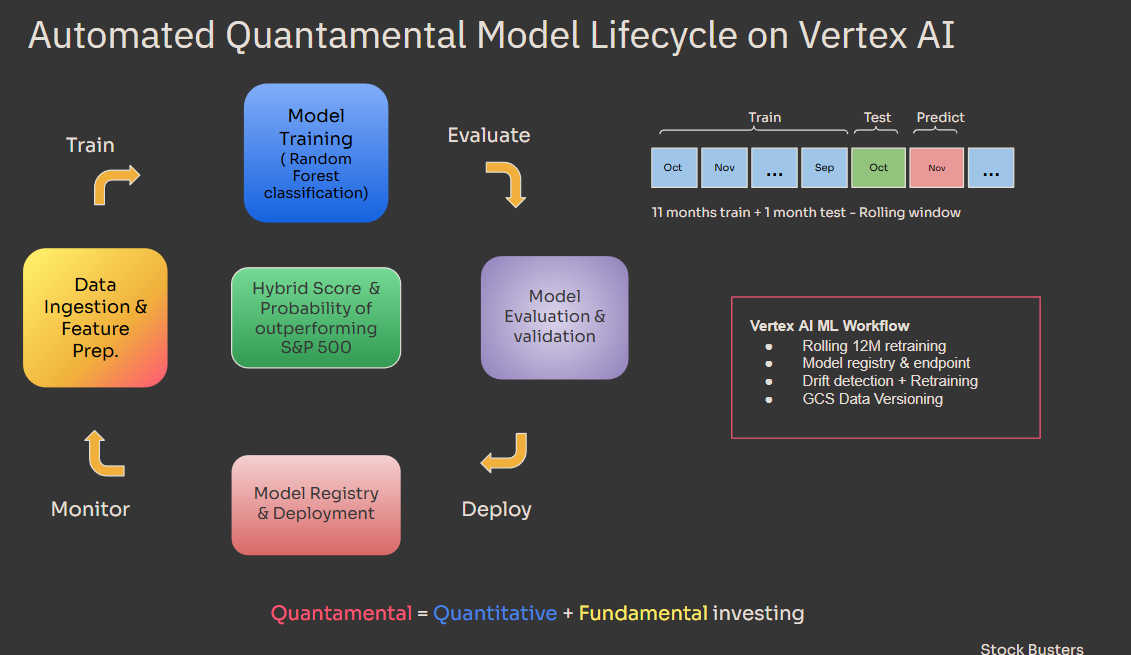

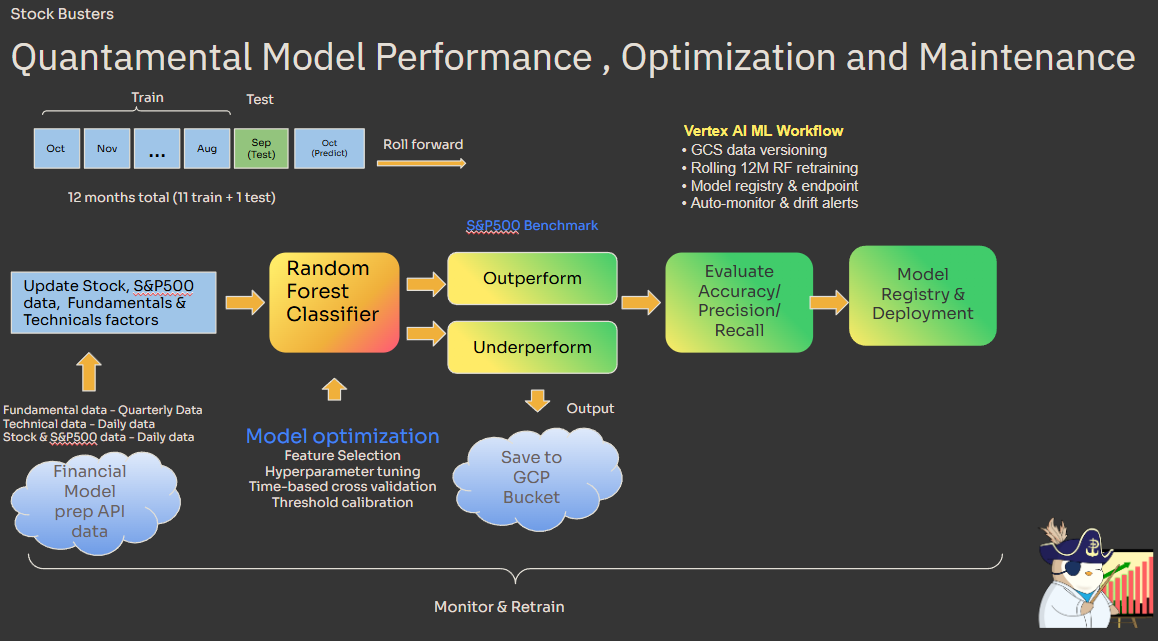

---
**Backtesting Plan**

In addition, we will develop a backtesting module — a process used to evaluate how well the model’s predictions would have performed in real historical scenarios.

Backtesting allows us to simulate trades or portfolio performance based on the model’s buy/sell (LONG/SHORT) signals and compare the results against a benchmark such as the S&P 500 index.

This helps us answer key questions such as:

Did the model’s predicted “outperform” stocks actually beat the market?

What would be the cumulative return, Sharpe ratio, and drawdown if we followed the model’s strategy?

How consistent are the signals across different market conditions?

By including this backtest in the final output report, we can verify whether the model provides trustworthy, actionable insights rather than random or overfitted predictions.



---